# Control Charts for Number of Nonconformities
## The $np$, $C$, and $U$ Charts (with OC Curves)
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [The $np$ Chart](#the-np-chart)
3. [Worked Example: $np$ Chart](#worked-example-np-chart)
4. [The $C$ Chart](#the-c-chart)
5. [Worked Examples: $C$ Chart](#worked-examples-c-chart)
6. [The $U$ Chart](#the-u-chart)
7. [Worked Examples: $U$ Chart](#worked-examples-u-chart)
8. [OC Curves for the $C$ and $U$ Charts](#oc-curves-for-the-c-and-u-charts)
9. [Final Remarks](#final-remarks)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

#setwd("Slides//Week-7-Nonconformity-Counts")


## Introduction

Last week we introduced the $p$ chart for monitoring the **fraction** nonconforming. This is useful anywhere the quality characteristic is inherently dichotomous, like whether or not a student graduates within five years.

But the $p$ chart has a real limitation: interpretability. A proportion isn't *hard* to interpret, but a simple **count** of nonconformities is often more intuitive. "We had 12 defects" lands more directly than "our defect proportion was 0.034." There's also a statistical reason to care: counts are positive integers, and for small counts the distribution tends to be positively skewed. Leaning on the CLT to justify an $\bar{x}$-style chart in that setting produces a **less efficient** chart. This means the chart will be slower to signal when a real shift has occurred.

That's where a family of count-specific, Shewhart-style charts comes in:

| Chart | What it monitors | Works like... |
|---|---|---|
| $np$ chart | Number of nonconforming **units** in a sample | A direct extension of the $p$ chart |
| $C$ chart | Number of nonconformities **per unit** | A new Poisson-based approach |
| $U$ chart | Average number of nonconformities **per batch/sample** | $C$ chart, generalized to $n>1$ |

We'll walk through when each one fits, how to build it, and, same as with our other charts, how to use OC curves to design a chart that reliably catches shifts of the size we actually care about.

## The $np$ Chart

The most straightforward count chart is a simple rescaling of the $p$ chart. If the fraction nonconforming is $p$, then the *number* of nonconforming units out of a sample of size $n$ is just $np$. We still take samples of size $n$ at each time point and count how many units fail to conform — we're just plotting the count instead of the proportion.

We already know the sampling distribution of $\hat{p}$:

$$ \hat{p} \;\dot{\sim}\; N\bigg(p,\sqrt{\frac{p(1-p)}{n}}\bigg) $$

Multiplying a normal random variable by the constant $n$:

$$E[n\hat{p}] = nE[\hat{p}] = np $$
$$ Var[n\hat{p}] = n^2Var[\hat{p}] = n^2\frac{p(1-p)}{n} = np(1-p) $$

So:

$$ n\hat{p} \;\dot{\sim}\; N\big(np, \sqrt{np(1-p)}\big) $$

When $p$ is known, our Shewhart-style control limits are:

$$ UCL = np + 3\sqrt{np(1-p)} $$
$$ LCL = np - 3\sqrt{np(1-p)} $$

## The $np$ Chart — Estimating $p$

Most of the time we won't know $p$, so we estimate it from Phase I data. We take $m$ samples of size $n$ and calculate an estimate of $np$:

$$ n\bar{p} = \frac{n}{m}\sum_{i=1}^{m}\hat{p}_i $$

Then we just substitute this estimate into the control limits:

$$ UCL = n\bar{p} + 3\sqrt{n\bar{p}(1-\bar{p})} $$
$$ LCL = n\bar{p} - 3\sqrt{n\bar{p}(1-\bar{p})} $$

Conceptually, an $np$ chart takes a sample of $n$ units, and the plotting statistic $X$ is simply the count of those $n$ units that don't conform. Note that in cases like the purchase-order example from last week, treating each PO as a simple pass/fail hides information — a PO with one typo and a PO with five separate errors both just get counted as "1 nonconforming unit." We'll come back to that gap shortly.

## Worked Example: $np$ Chart

Let's revisit the examples from last week — same data, but plotted as counts instead of proportions. As you'll see, the *pattern* in the orange juice cans example plays out identically to the $p$ chart version; the only real difference is interpretation. We're now monitoring the **number** of nonconforming units per sample rather than the **proportion**.

In [4]:
## Load the Libraries ##

library(tidyverse)
library(readxl)
library(qcc)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Phase I $np$ chart — Orange Juice Cans

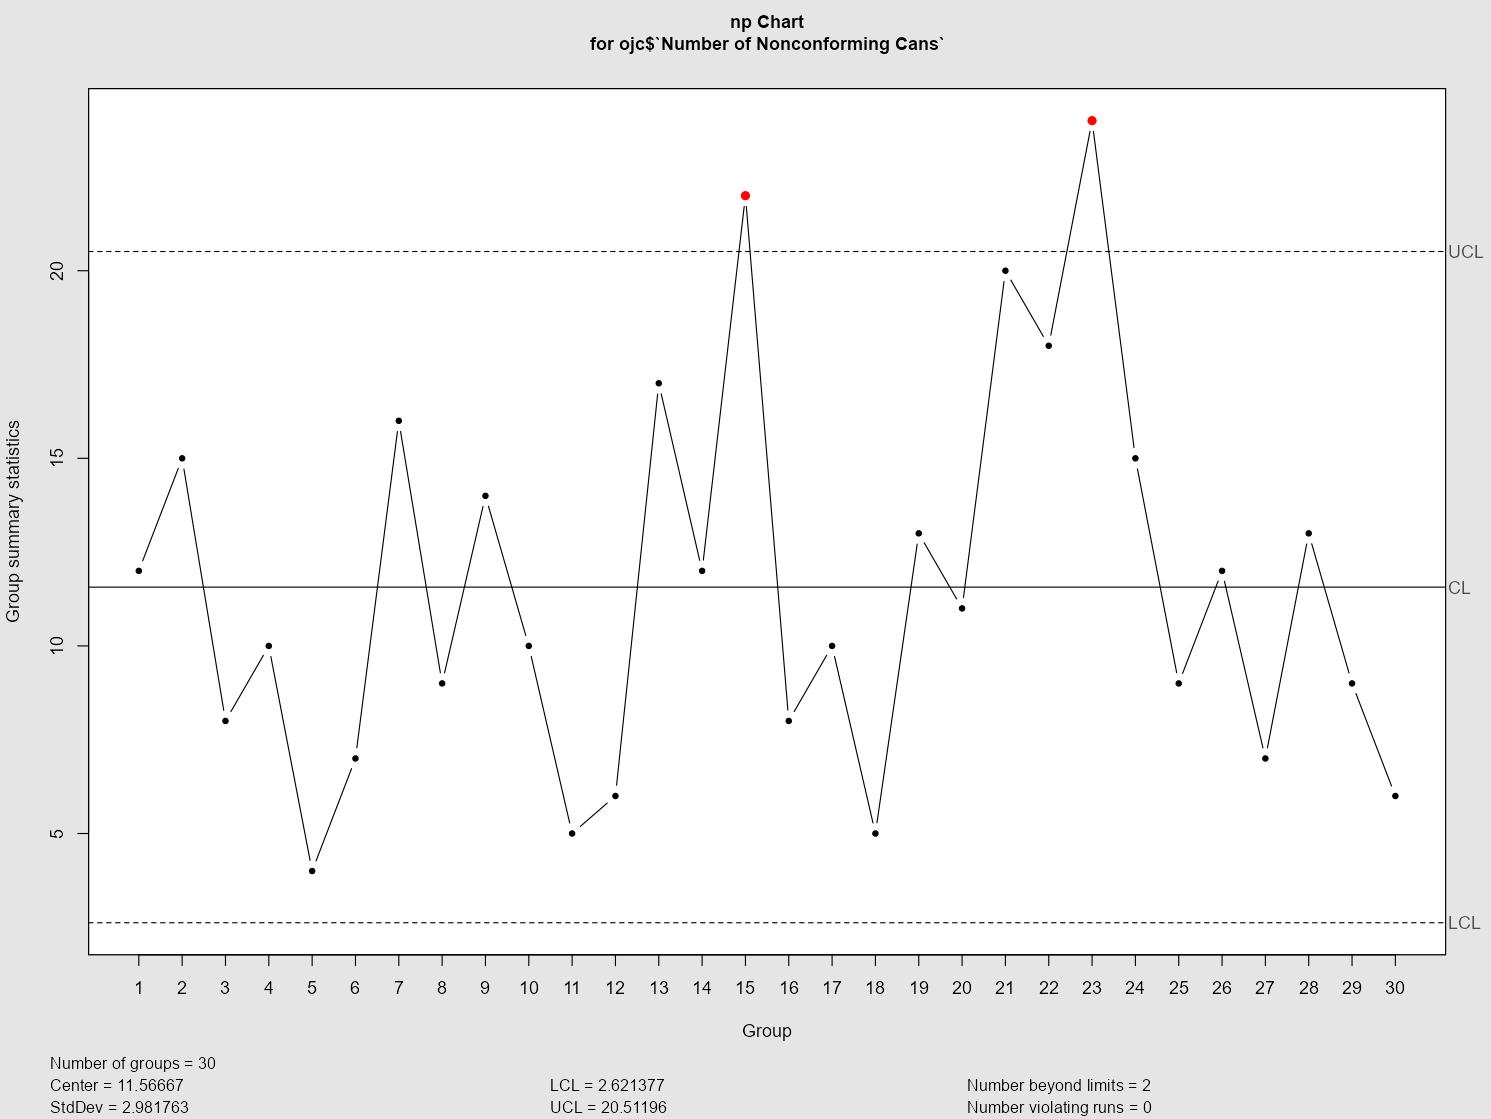

In [5]:
## Phase I Control Chart - Orange Juice Cans ##

ojc <- read_xlsx("Orange Juice Cans.xlsx")

ojc_chart <- qcc(ojc$`Number of Nonconforming Cans`,
                      type="np",sizes=ojc$`Sample Size`,
                      plot=TRUE)

Same story as last week: two OOC points that we attributed to low levels of adhesive in the machine that applies the adhesive. We'll remove them iteratively and recalculate the limits until the process settles into control.

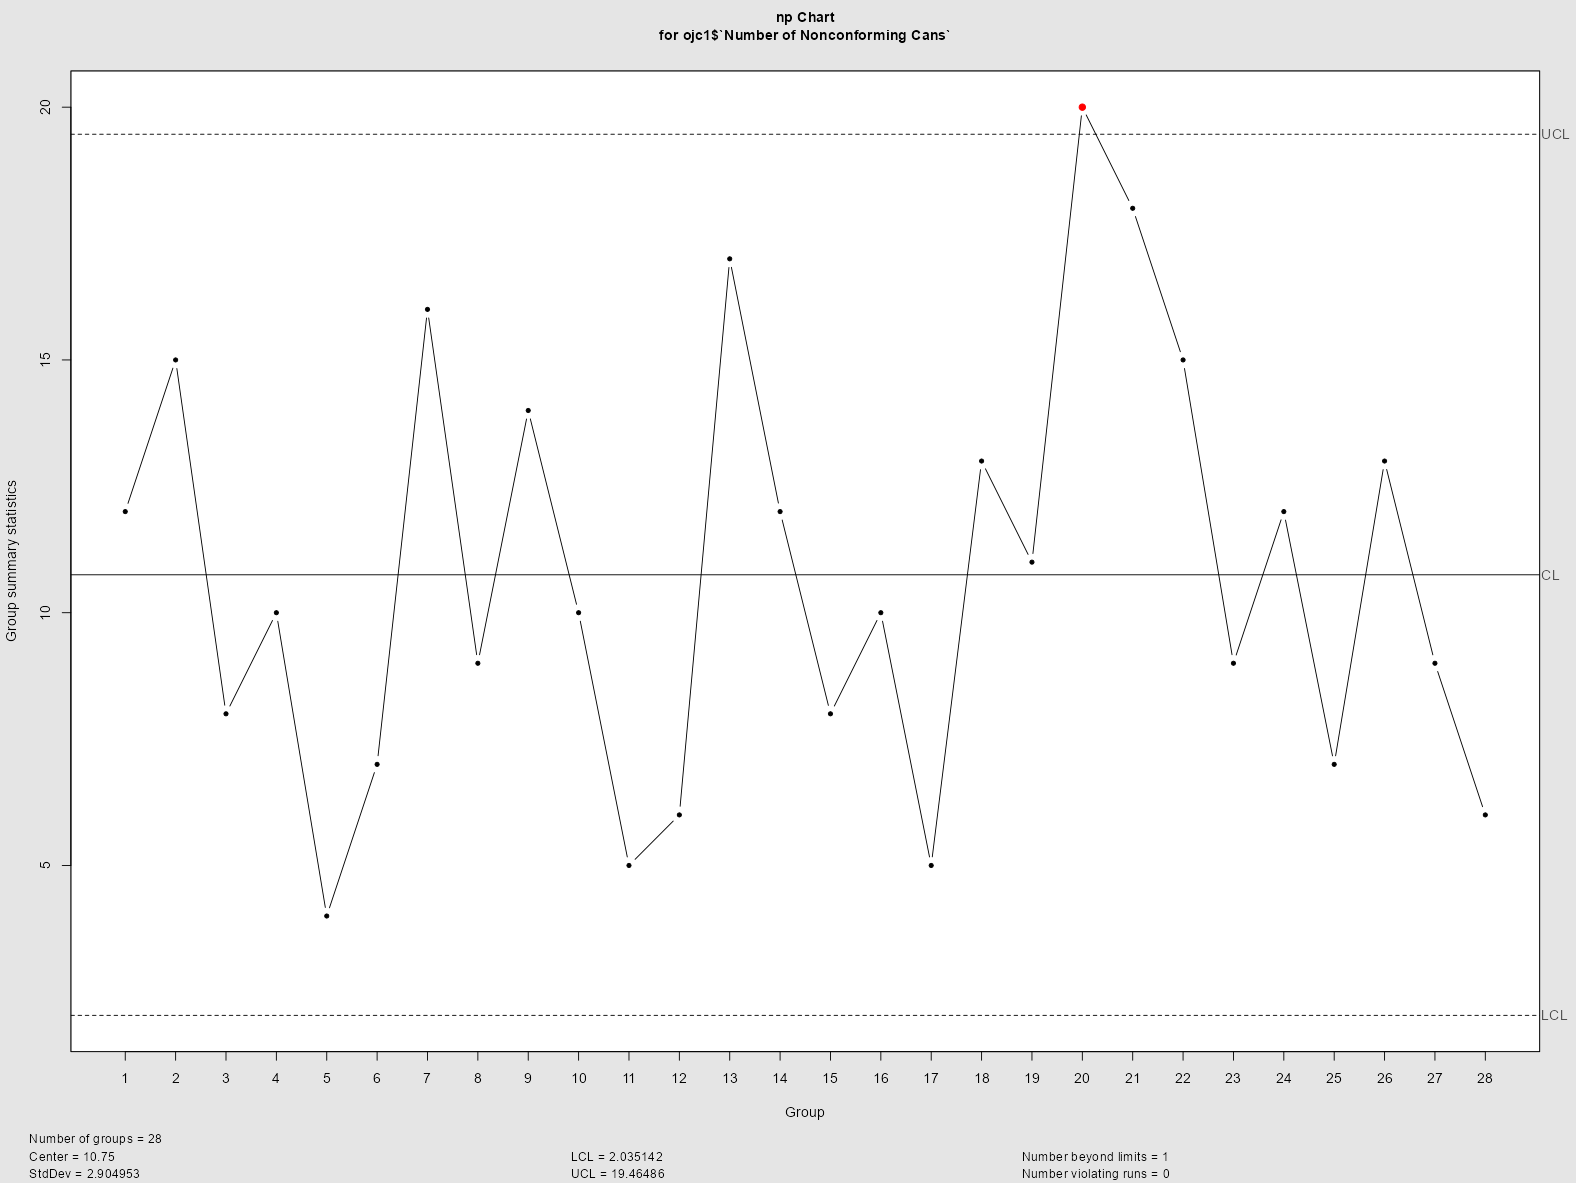

In [6]:
## Whoops! Two OOC Points ##

ooc_points <- ojc_chart$violations$beyond.limits

ojc1 <- ojc[-ooc_points,]

ojc1_chart <- qcc(ojc1$`Number of Nonconforming Cans`,
                       type="np",sizes=ojc1$`Sample Size`,
                       plot=TRUE)

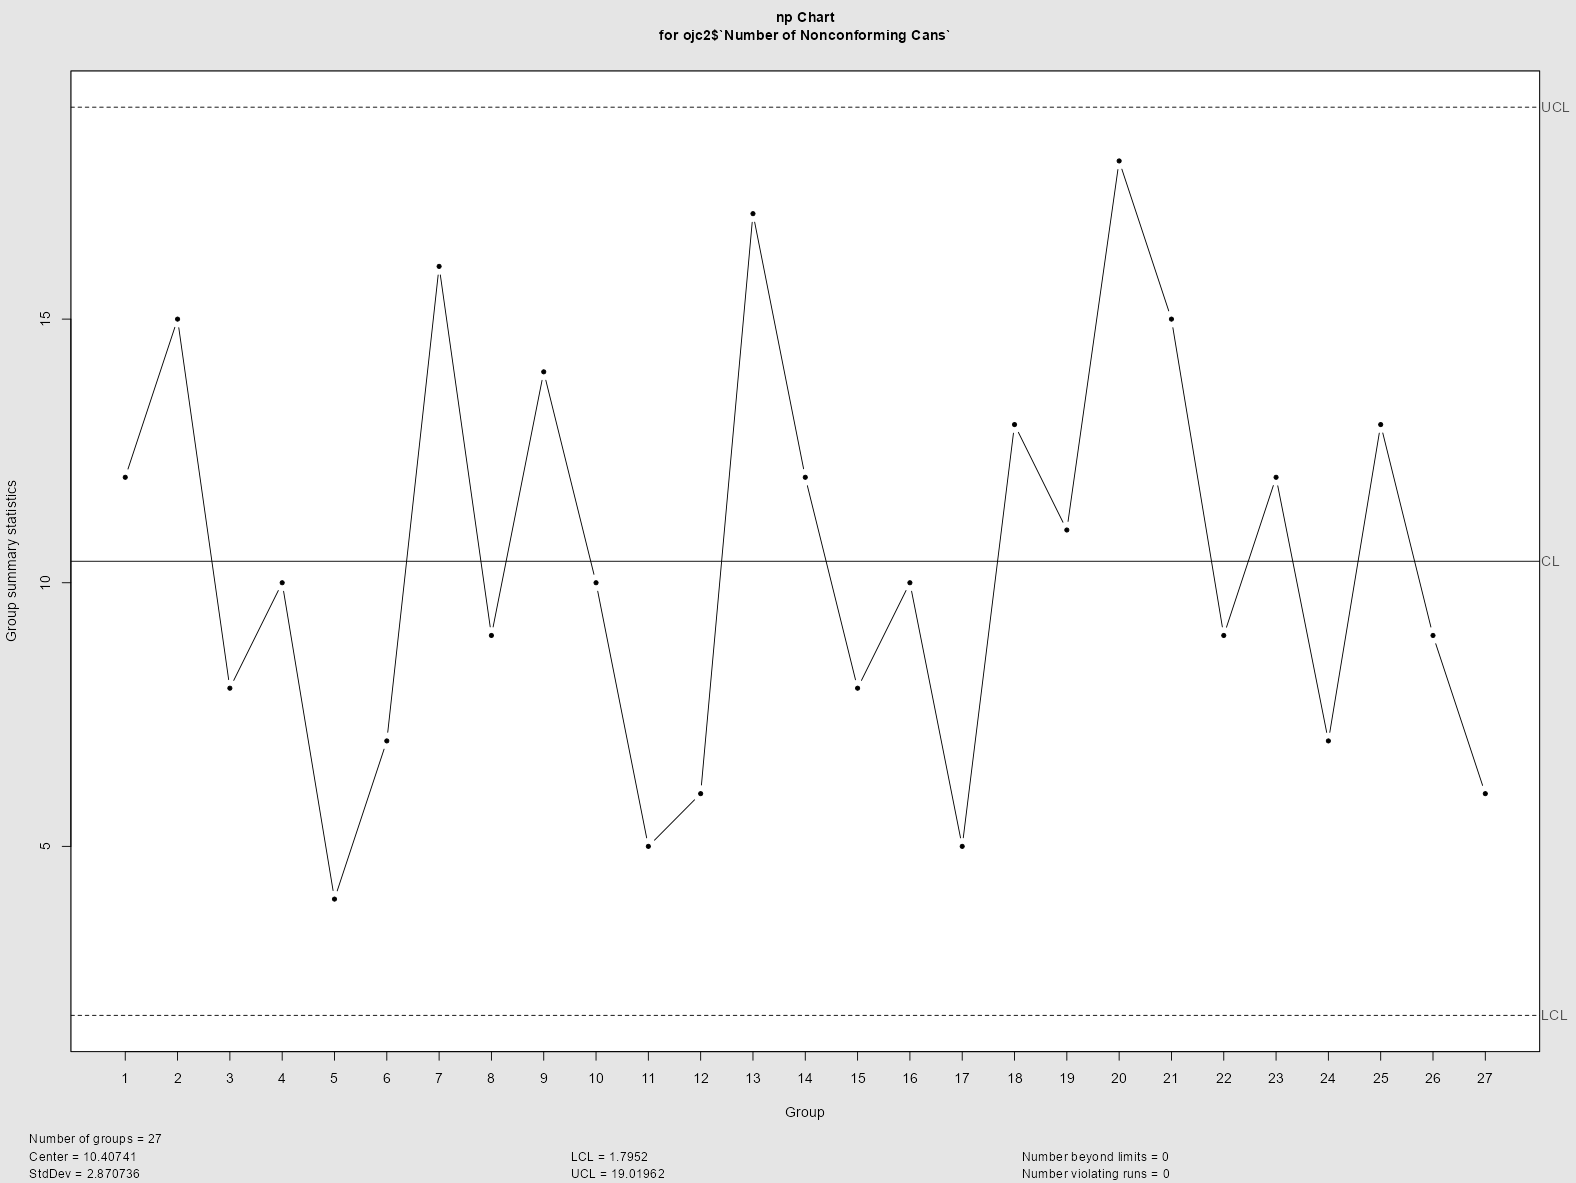

In [7]:
## Now we just have one ##

ooc_points1 <- ojc1_chart$violations$beyond.limits

ojc2 <- ojc1[-ooc_points1,]

ojc2_chart <- qcc(ojc2$`Number of Nonconforming Cans`,
                       type="np",sizes=ojc2$`Sample Size`,
                       plot=TRUE)

The process now plots in control, so we're ready to move on to Phase II — applying the finalized Phase I limits to new data.

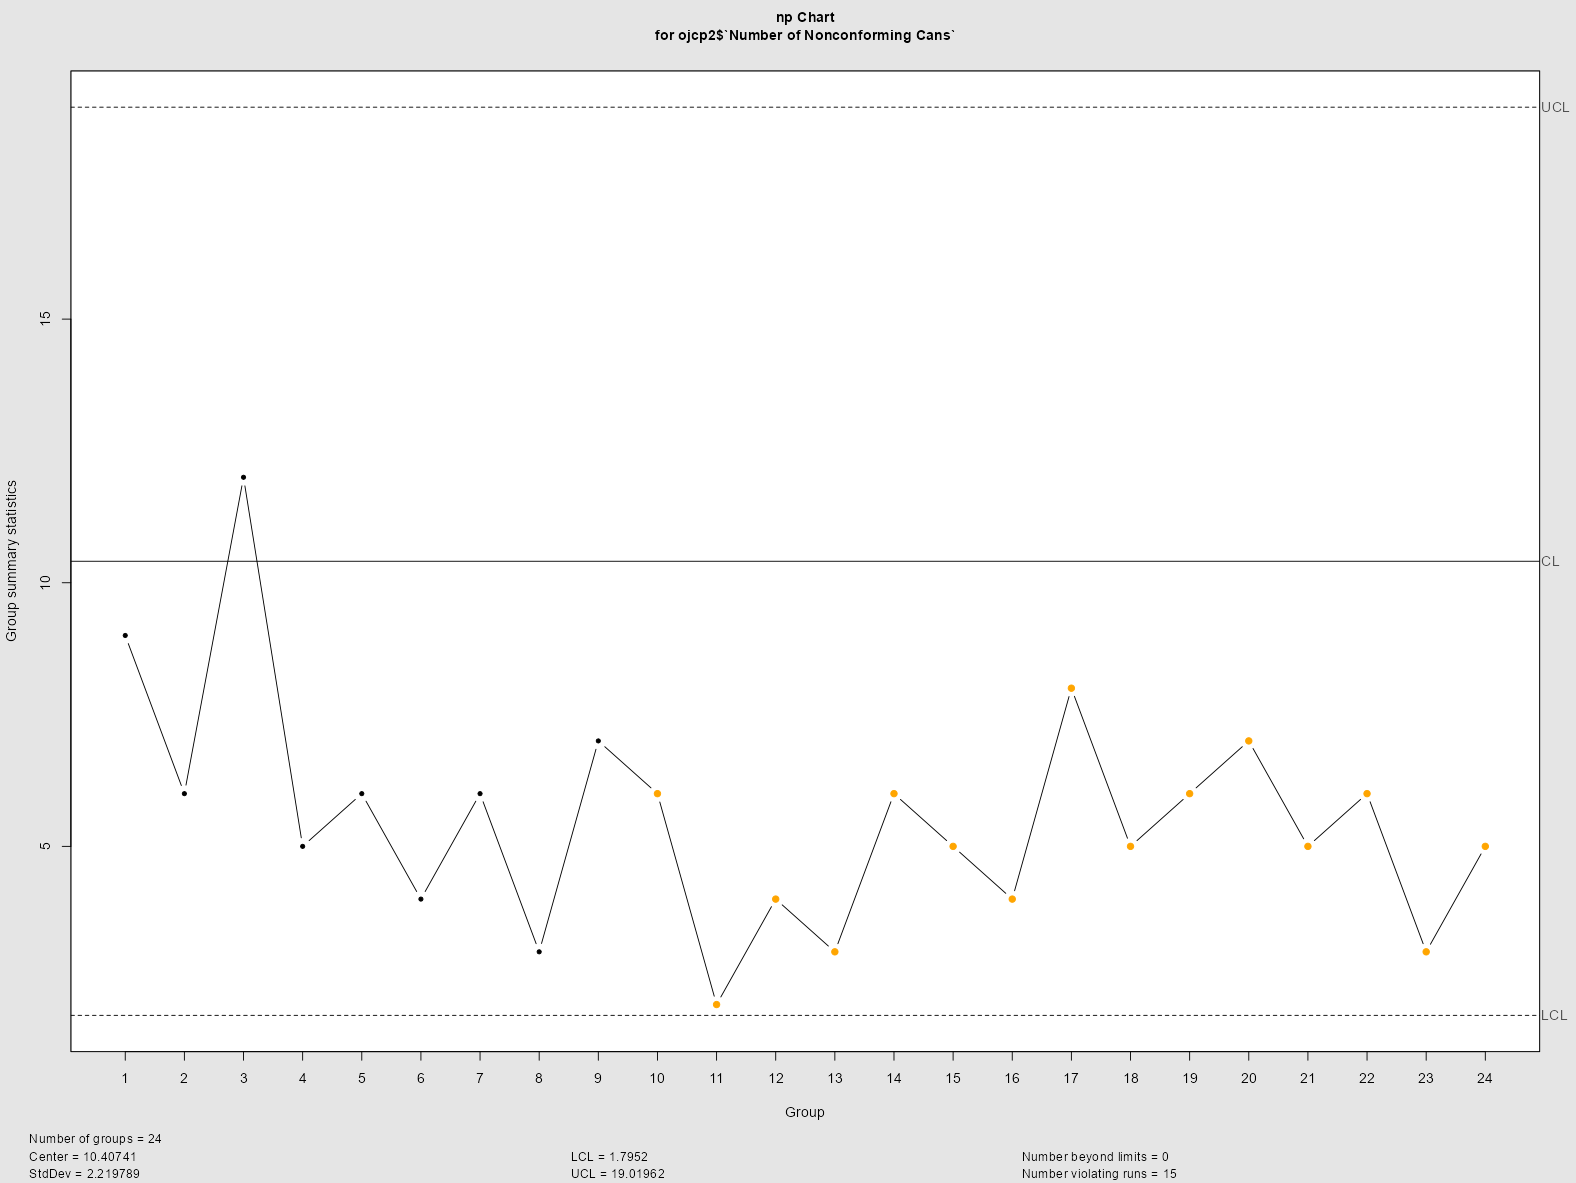

In [8]:
## Okay great! The process now plots in control so we can move on to Phase II ##

ojcp2 <- read_xlsx("Orange Juice Cans.xlsx",
                           sheet=2)

## Take the Phase I Limits ##

ojc2_chart$limits

uclnp <- ojc2_chart$limits[2]
lclnp <- ojc2_chart$limits[1]
npbar <- ojc2_chart$center

ojc_npchartp2 <- qcc(ojcp2$`Number of Nonconforming Cans`,
                        type="np",sizes=50,
                        limits = c(lclnp,uclnp),
                        center = npbar,
                        plot=TRUE)

Notice the same phenomenon we saw last week with the $p$ chart: even without any points plotting out of control, there's a visible pattern hinting the process may have genuinely shifted.

### Phase I $np$ chart — Enrollment data

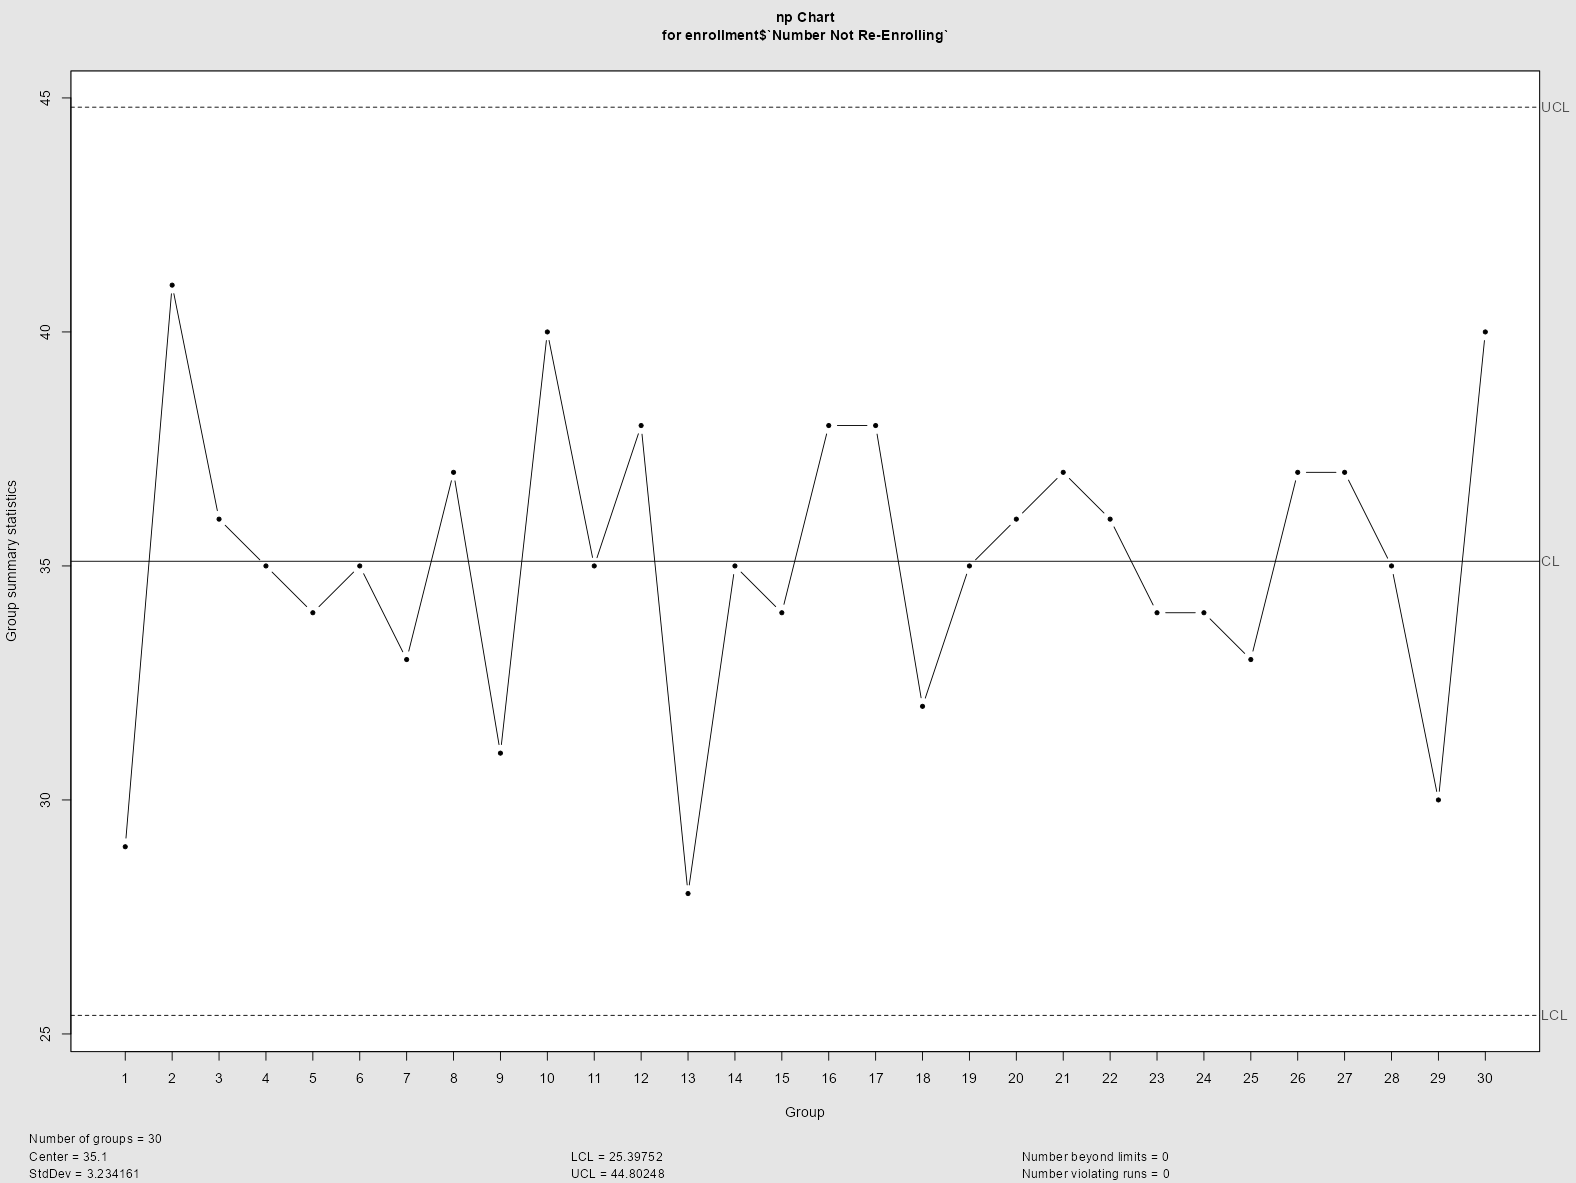

In [9]:
## Phase I np Control Chart - Enrollment Data ##

enrollment <- read_xlsx("Enrollment.xlsx")

## Phase I Control Chart ##

enroll_chart <- qcc(enrollment$`Number Not Re-Enrolling`,
                         type="np",sizes=50,
                         plot=TRUE)

## The $C$ Chart

The $np$ chart is a good fit when "nonconforming" is a fair pass/fail label. However, sometimes that's throwing away real information. Back to the purchase-order example: a PO with a single typo and a PO with five separate errors are both just "nonconforming" under an $np$ chart. If we actually care about the **number of nonconformities per unit**, not just whether a unit passes or fails, we need a different chart: the **$C$ chart**.

For counts like this, the Poisson distribution is typically an appropriate model, under two basic assumptions:

1. The sampling unit (a PO, a car door, a circuit board) is consistent from sample to sample
2. The probability of observing a nonconformity is fixed from sample to sample

If $X$ is Poisson with mean number of nonconformities per unit $C$:

$$ P[X = x] = \frac{e^{-C}C^{x}}{x!} $$

When $C$ is known, our Shewhart-style control limits are:

$$ UCL = C + 3\sqrt{C} $$
$$ LCL = C - 3\sqrt{C} $$

### A practical wrinkle: the Poisson isn't symmetric

So far our $3\sigma$ limits have mostly assumed an underlying normal distribution. The Poisson, for small $C$, is noticeably right-skewed. This makes naive $3\sigma$ limits a rougher approximation than we're used to.

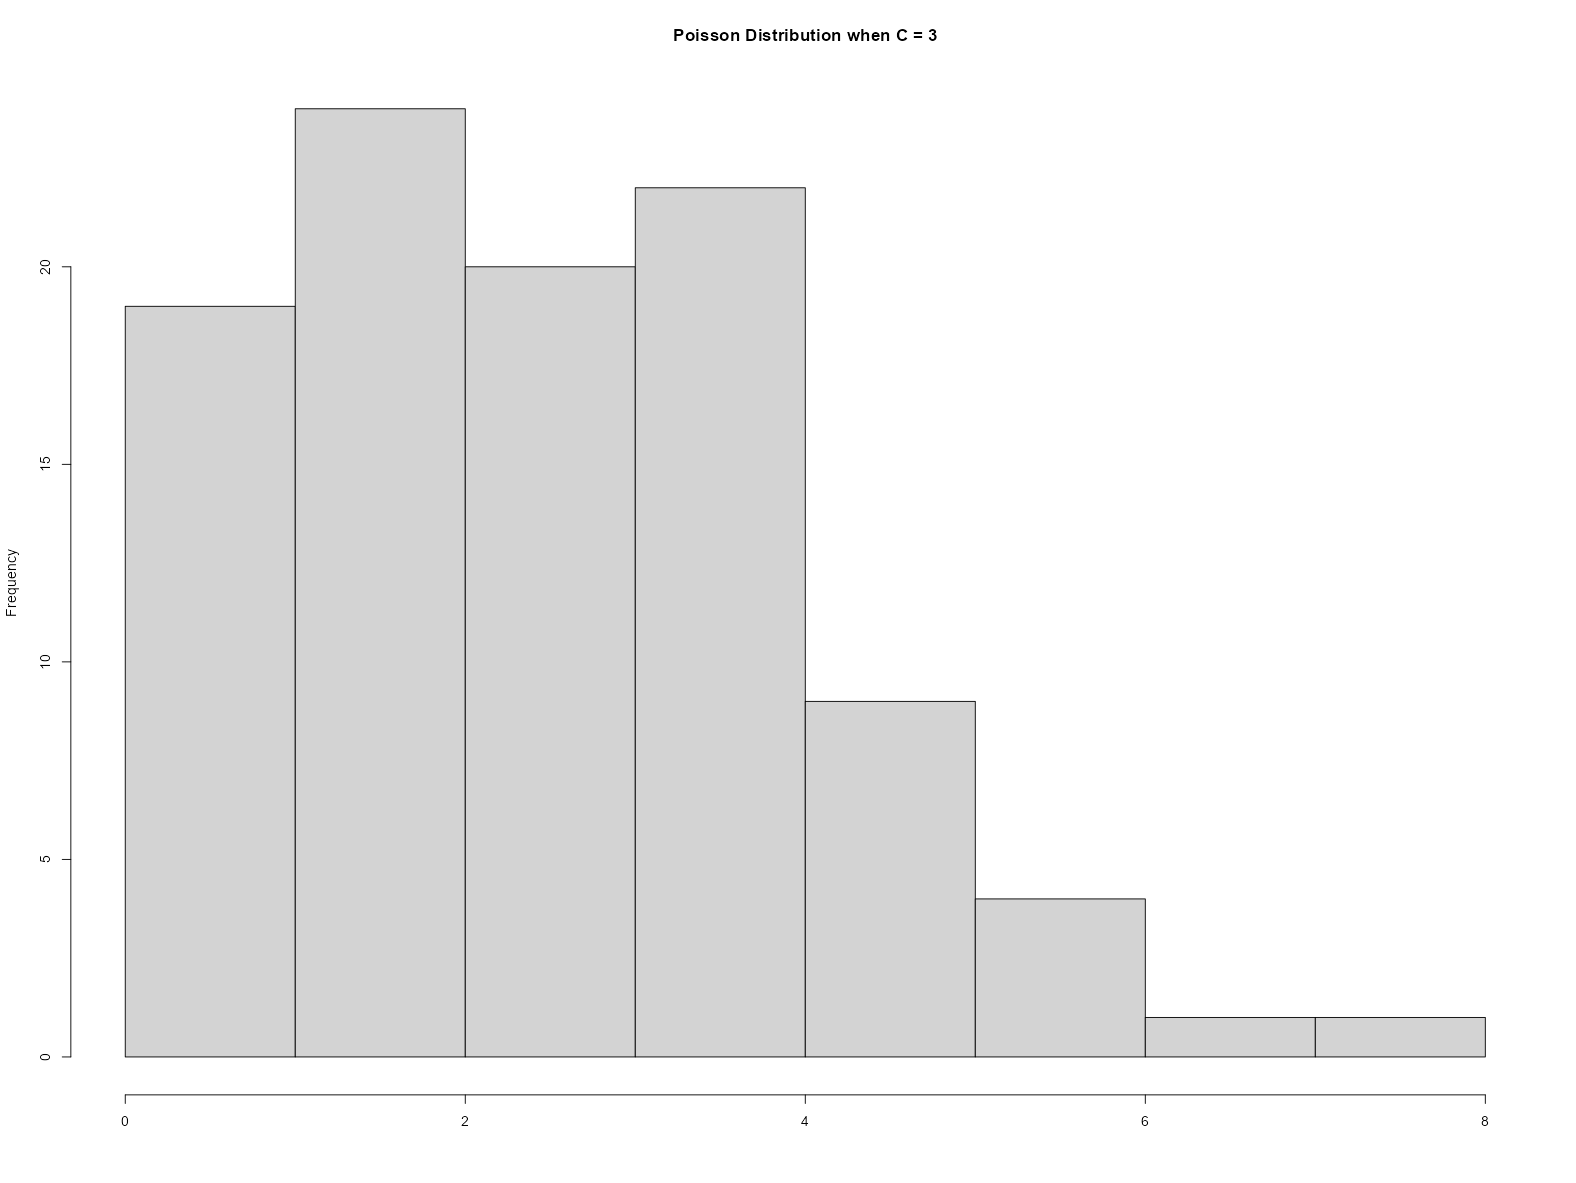

In [10]:
set.seed(123)
ps <- rpois(100,lambda=3)
hist(ps,main="Poisson Distribution when C = 3",xlab="")

As a result, it's sometimes more appropriate to use **$\alpha$-derived limits** (like we did for the $s^2$ chart) instead of $\sigma$-based ones. Recall the idea: choose $UCL$ and $LCL$ such that

$$ P[LCL \leq X < UCL \,|\, IC] = 1 - \alpha $$
$$\implies P[X < UCL \,|\, IC] - P[X \leq LCL] = 1 - \alpha $$

Software makes this easy — we can solve for the exact $UCL$/$LCL$ for a specified $\alpha$ and known (or estimated) $C$.

### Estimating $C$ from Phase I data

As usual, we typically won't know $C$ and will estimate it from Phase I data. Take $m$ samples and calculate the average count across them:

$$ \bar{C} = \frac{1}{m}\sum_{i=1}^{m}C_i $$

$\bar{C}$ is both the MLE and the method-of-moments estimator for $C$, so our $3\sigma$ control limits become:

$$ UCL = \bar{C} + 3\sqrt{\bar{C}} $$
$$ LCL = \bar{C} - 3\sqrt{\bar{C}} $$

## Worked Examples: $C$ Chart

**Circuit boards:** suppose our sampling unit isn't a single board, but a batch of 100 boards. We take $m=26$ samples of 100 boards and count the nonconformities observed in each. Data live in Sheet 1 of the `Number of Nonconformities Datasets.xlsx` workbook.

> *(A quick aside: this is exactly the kind of setting where Pareto analysis, like we used with the coffee shop data in our first class session, pairs naturally with the $C$ chart, helping identify which specific nonconformity types are driving the counts. A cause-and-effect diagram can take that a step further by tracing those nonconformities back to specific parts of the process.)*

Rows: 26
Columns: 2
$ `Sample Number`             <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26
$ `Number of Nonconformities` <dbl> 21, 24, 16, 12, 15, 5, 28, 20, 31, 25, 20, 24, 16, 19, 10, 17, 13, 22, 18, 39, 30, 24, 16, 19, 17, 15


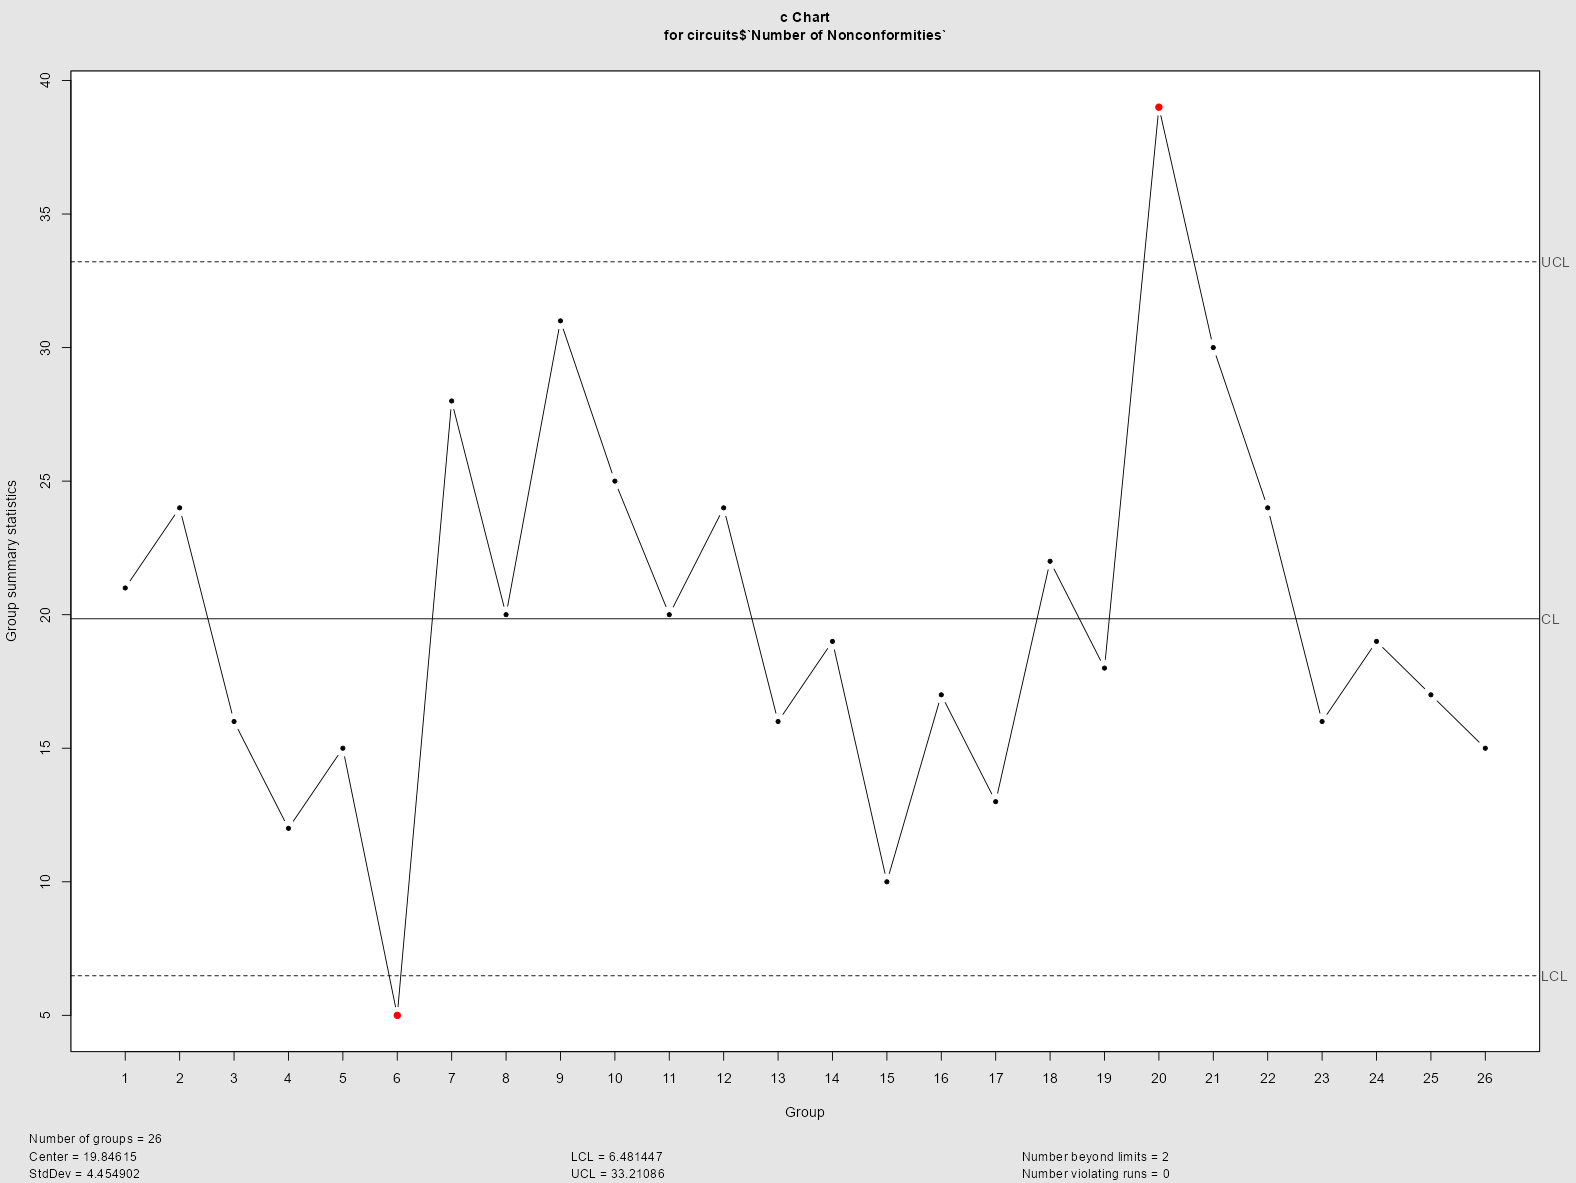

In [11]:
## Read in Circuit Board Phase I Data ##

circuits <- read_xlsx("Number of Nonconformities Datasets.xlsx")

circuits |>
  glimpse()

## Plot Phase I C-Chart ##

circuit_chart <- qcc(circuits$`Number of Nonconformities`,
                          type="c",plot=T)

We have two OOC points: One below LCL at $t=6$ and one above UCL at $t=20$. Suppose for the lower OOC point, a training was being given during that time period so much more care was given to producing the boards. At the later time point, suppose that new hires were operating the process for the first time leading to an unusually high number of nonconformities. Since we have assignable and correctable causes, we can safely omit those points and recalculate the limits.

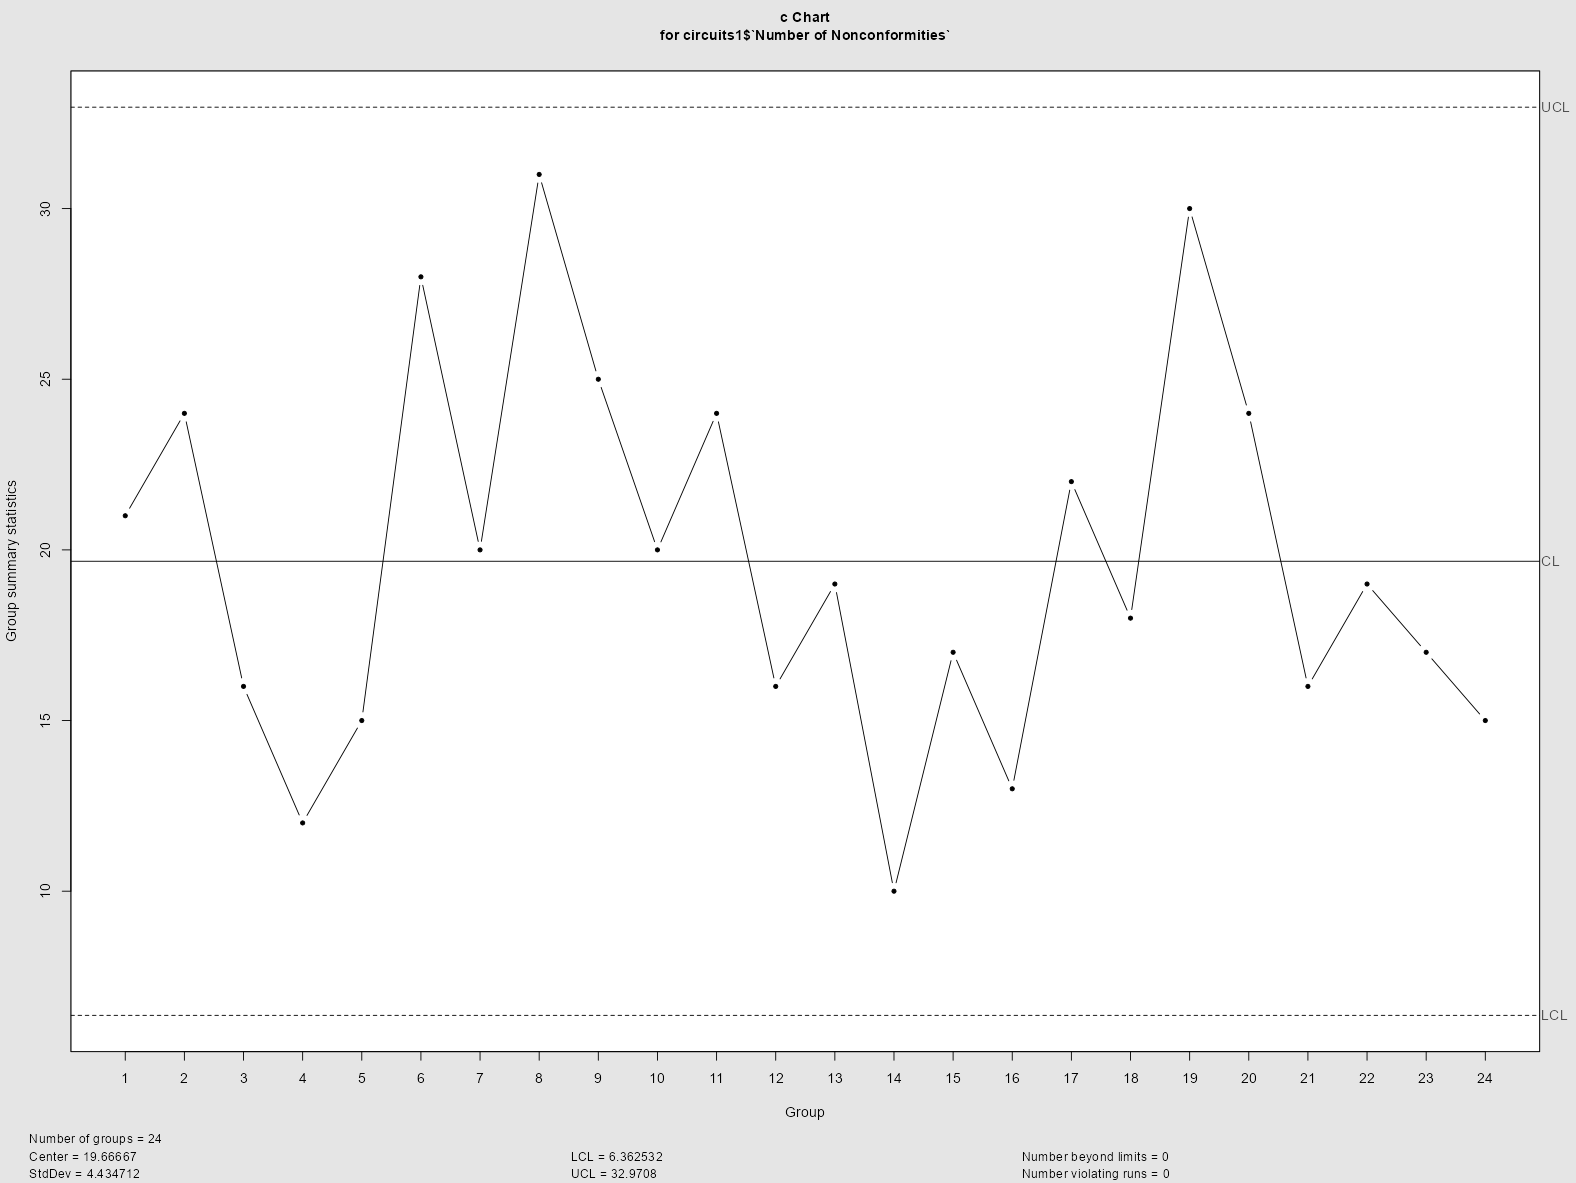

In [12]:
## Two OOC Points were Detected ##

ooc_points <- circuit_chart$violations$beyond.limits

circuits1 <- circuits[-ooc_points,]

circuit_chart1 <- qcc(circuits1$`Number of Nonconformities`,
                           type="c",plot=T)

All points now plot inside the control limits. Let's estimate $\bar{c}$, $UCL$, and $LCL$ from this cleaned Phase I chart, then apply them to fresh Phase II data.

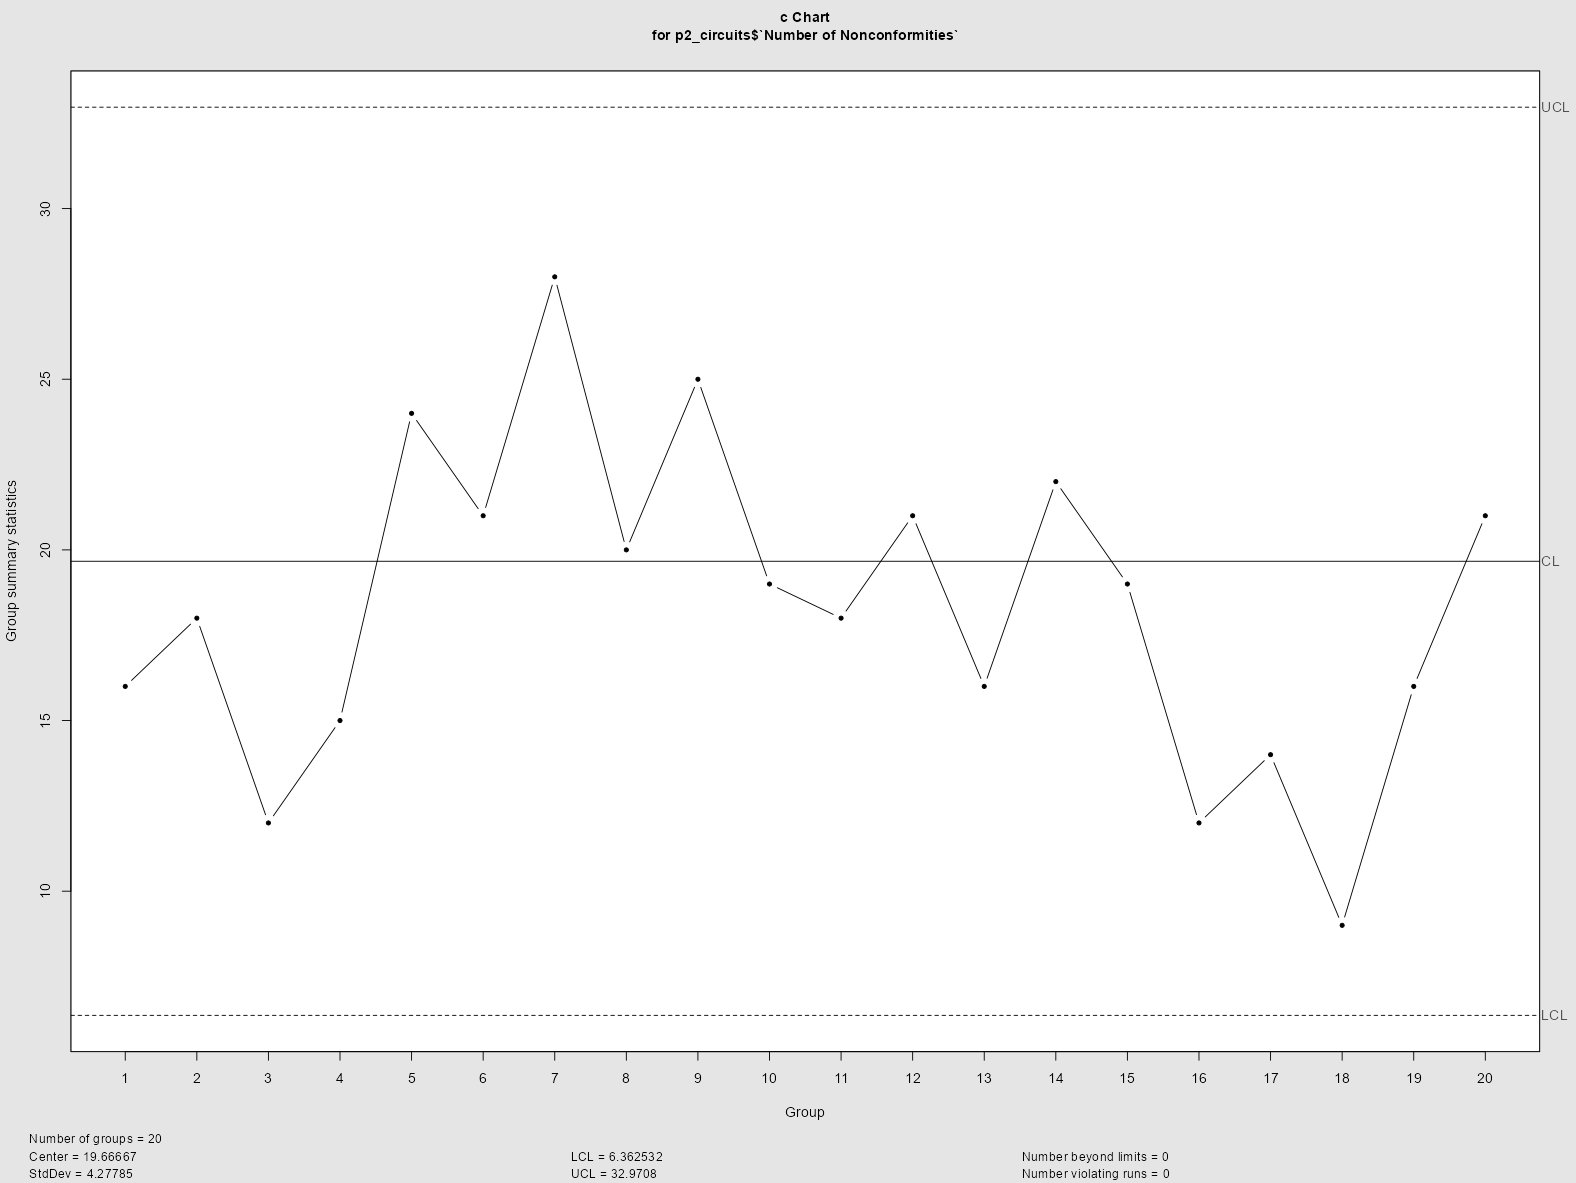

In [13]:
## Let's read in Phase II data ##

p2_circuits <- read_xlsx("Number of Nonconformities Datasets.xlsx",
                                 sheet=2)

## Save the Phase I Control Limits ##

uclc <- circuit_chart1$limits[2]
lclc <- circuit_chart1$limits[1]
cl <- circuit_chart1$center

p2_circuit_chart <- qcc(p2_circuits$`Number of Nonconformities`,
                             type="c",
                             limits = c(lclc,uclc),
                             center = cl,
                             plot=TRUE)

### A second example: monitoring exam consistency

Suppose you chair a statistics department teaching several presumably-identical sections of an intro course. The same 10-item midterm is given in every section. We want to monitor, semester to semester, the number of incorrect responses as a way of tracking class-to-class consistency (yes, there are plenty of confounders here, but let's roll with it for the sake of the example).

Assuming 20 sections are taught each semester (including summer), 10 years of data live in Sheet 3 of the workbook.

Rows: 30
Columns: 2
$ `Sample Number`                 <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30
$ `Number of Incorrect Responses` <dbl> 37, 31, 40, 50, 39, 46, 43, 39, 30, 37, 40, 48, 54, 49, 39, 28, 46, 36, 46, 44, 31, 38, 34, 40, 42, 40, 29, 44, 48, 50


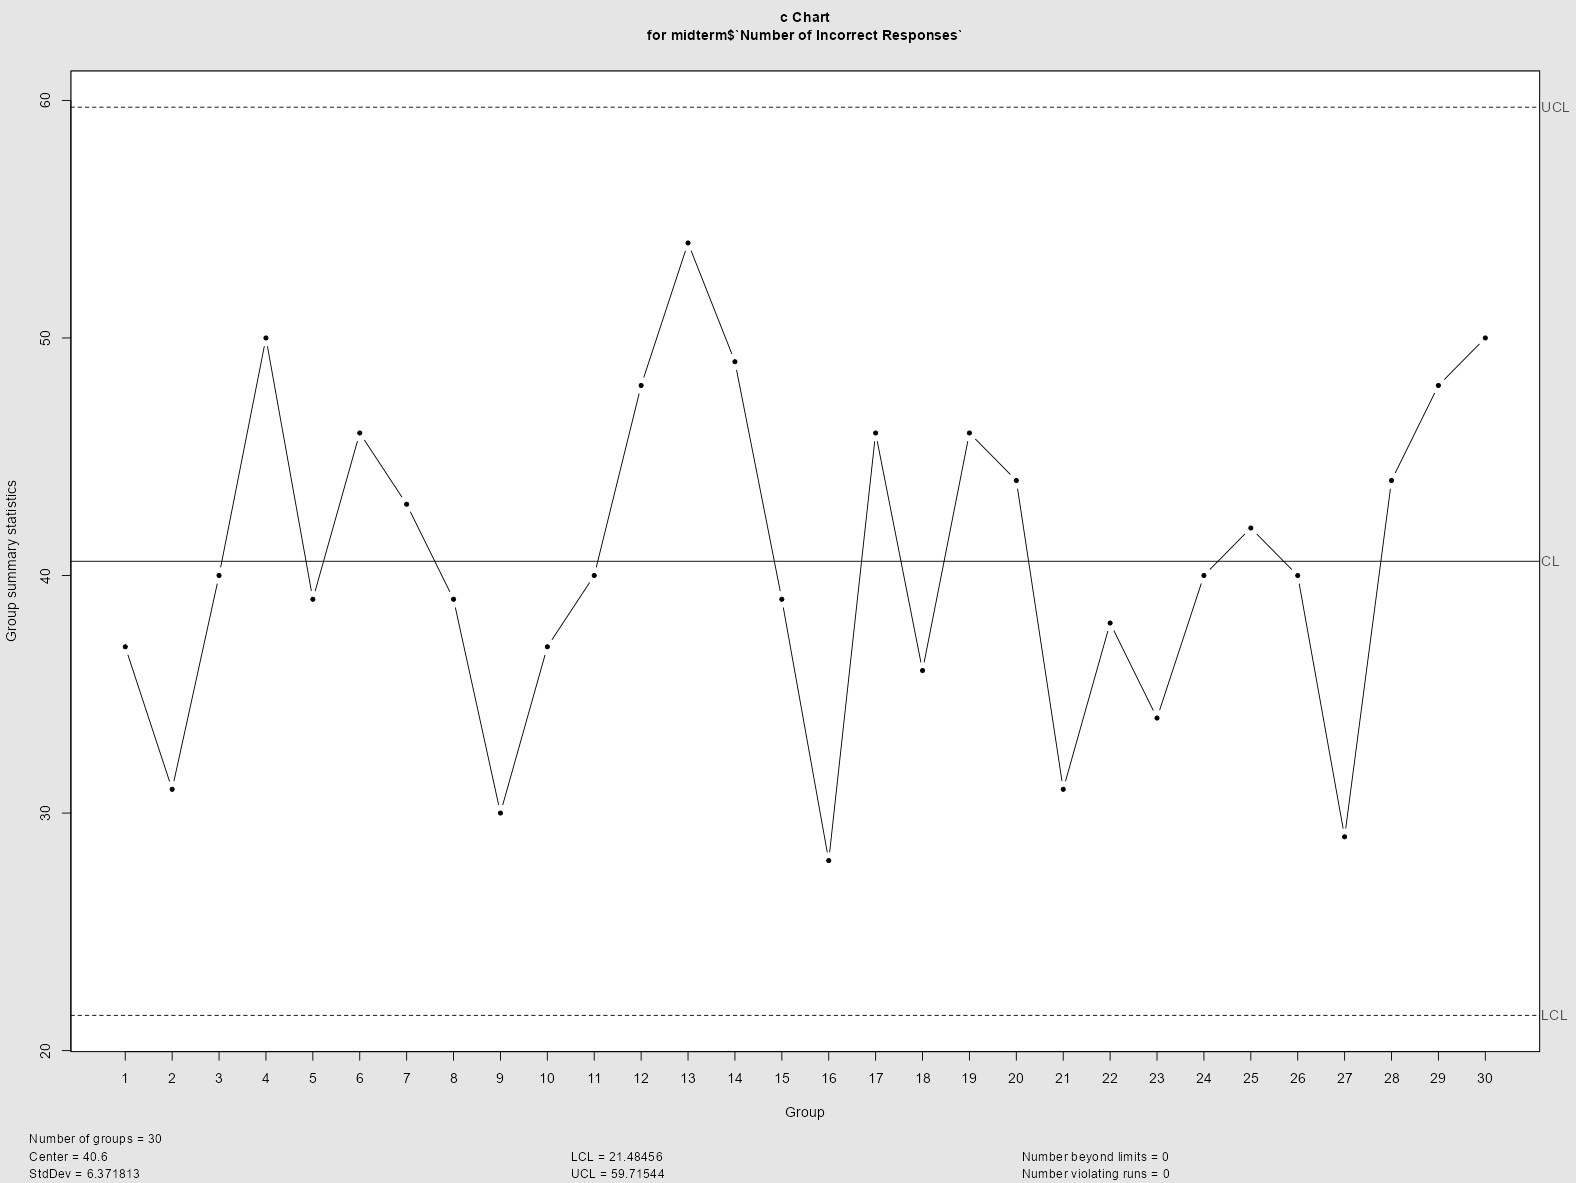

In [14]:
## Read in Midterm Data ##

midterm <- read_xlsx("Number of Nonconformities Datasets.xlsx",
                             sheet=3)

midterm |>
  glimpse()

## Plot C Chart for Phase 1 ##

midterm_chart <- qcc(midterm$`Number of Incorrect Responses`,
                          type="c")

Now let's apply these Phase I limits to the next 15 semesters of data.

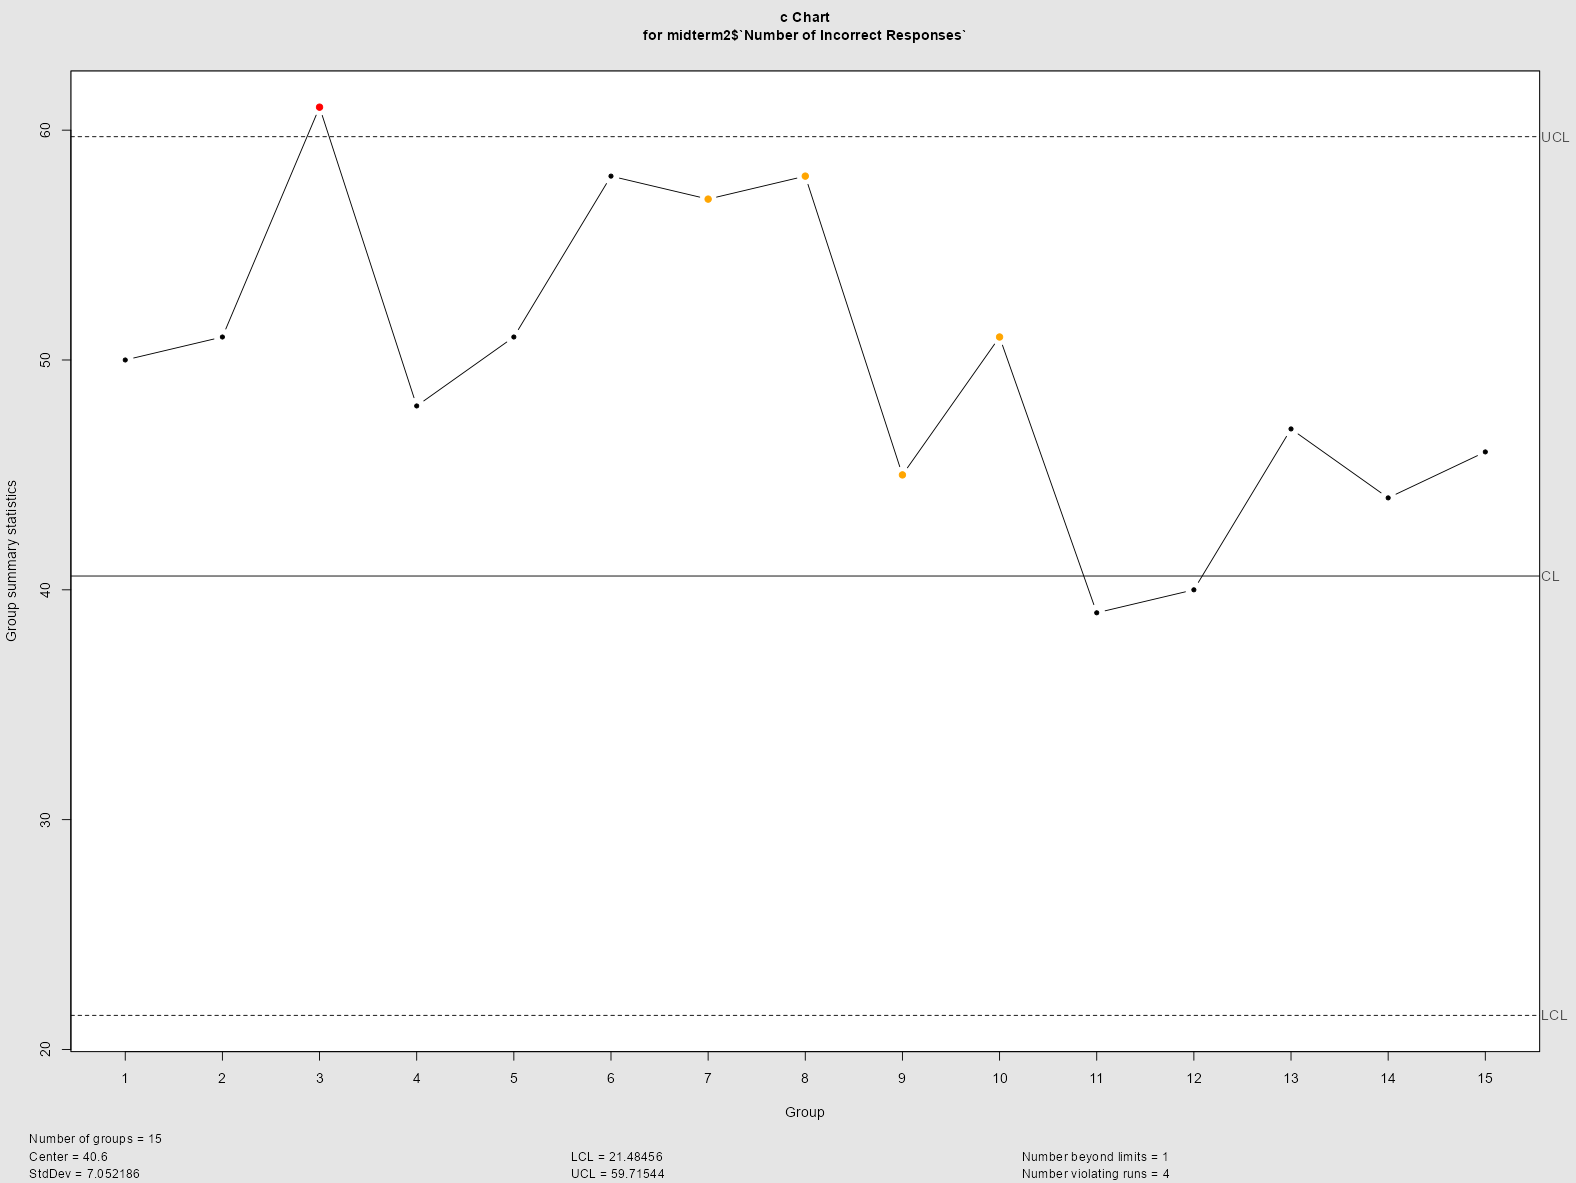

In [15]:
## Let's read in Phase II Data to Monitor Next 15 semesters worth of data ##

midterm2 <- read_xlsx("Number of Nonconformities Datasets.xlsx",
                              sheet=4)

## Save Control Limits and CL from Phase I ##

clc <- midterm_chart$center
uclc <- midterm_chart$limits[2]
lclc <- midterm_chart$limits[1]

p2_chart <- qcc(midterm2$`Number of Incorrect Responses`,
                     type="c",
                     limits=c(lclc,uclc),
                     center=clc,
                     plot=TRUE)

We've got one point plotting just above the $UCL$. It looks like the number of incorrect responses has crept from around 40 (80% correct) toward 50 (75% correct). Is this a real shift, or noise? We can borrow the same idea from last week and compare Phase I to Phase II directly with a hypothesis test.

One catch: when we did this before, we assumed our plotting statistic was normally distributed. Here, we definitely know it isn't. Fortunately, as the Poisson rate parameter $C$ gets reasonably large, the distribution becomes approximately bell-shaped. Thus, for large $C$ (roughly $>30$), a $t$-test is a reasonable choice. For smaller $C$, the nonparametric Mann-Whitney $U$ test (Wilcoxon rank-sum) is the safer bet.

In [16]:
## How can we know for sure? Let's test Phase I vs Phase II Data! ##

t.test(midterm$`Number of Incorrect Responses`,
       midterm2$`Number of Incorrect Responses`,
       alternative = "two.sided")


	Welch Two Sample t-test

data:  midterm$`Number of Incorrect Responses` and midterm2$`Number of Incorrect Responses`
t = -4.3236, df = 28.954, p-value = 0.0001656
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -13.454009  -4.812657
sample estimates:
mean of x mean of y 
 40.60000  49.73333 


In [17]:
## Mann-Whitney U Test/Wilcoxon Rank Sum ##

wilcox.test(midterm$`Number of Incorrect Responses`,
            midterm2$`Number of Incorrect Responses`,
            alternative = "two.sided")

Warning message:
In wilcox.test.default(midterm$`Number of Incorrect Responses`,  :
  cannot compute exact p-value with ties



	Wilcoxon rank sum test with continuity correction

data:  midterm$`Number of Incorrect Responses` and midterm2$`Number of Incorrect Responses`
W = 76, p-value = 0.0003404
alternative hypothesis: true location shift is not equal to 0


### Comparing $\alpha$-derived limits to $3\sigma$ limits

Let's see how much the $\alpha$-derived limits actually differ from the standard $3\sigma$ limits for this same midterm data, treating $\bar{C}$ as the true mean.

In [18]:
## Calculating Control Limits for Midterm Data Using Alpha Method ##

## Assume that C-bar is true mean ##

alpha <- 0.0027

UCL <- qpois(alpha/2,lambda=midterm_chart$center,lower.tail=FALSE)
LCL <- qpois(alpha/2,lambda=midterm_chart$center,lower.tail=TRUE)

In [21]:
## Compare to 3 Sigma Limits ##

cat("3 Sigma UCL:",midterm_chart$limits[2],"\n")
cat("Alpha UCL:",UCL,"\n")
cat("3 Sigma LCL:",midterm_chart$limits[1],"\n")
cat("Alpha LCL:",LCL,"\n")

3 Sigma UCL: 59.71544 
Alpha UCL: 61 
3 Sigma LCL: 21.48456 
Alpha LCL: 23 


Close, but not exact. That small difference isn't just academic. It changes our actual $\alpha$, which in turn changes our ARLs.

### $C$ Chart Limitations

Two things worth keeping in mind before leaning on a $C$ chart:

| Issue | What it means in practice |
|---|---|
| Distributional assumption | For small $C$, the Poisson is asymmetric, so $\sigma$-based limits are a rough approximation (use $\alpha$-derived limits instead). For very small $C$, we can also hit the familiar $LCL < 0$ problem. |
| Overdispersion / underdispersion | The Poisson assumes mean = variance = $C$. In practice, $\sigma^2 > \mu$ (overdispersion) or $\sigma^2 < \mu$ (underdispersion) is common, meaning the process doesn't actually follow a Poisson distribution. |

There's a body of literature on control charts designed specifically for over/underdispersed count data. We won't dig into them in this class, but it's worth knowing they exist — see [Sellers (2012), *A generalized statistical control chart for over- or under-dispersed data*, Quality and Reliability Engineering International](https://onlinelibrary.wiley.com/doi/abs/10.1002/qre.1215) as a starting point.

## The $U$ Chart

The $C$ chart examines a single unit. So think of a classroom, a refrigerator door, whatever "unit" means in context. But why stop at one unit per sample? Instead of nonconformities *per unit*, we can monitor the **average number of nonconformities per batch or sample** of size $n$. This grows our sample size without losing per-unit information, and leads to a close cousin of the $C$ chart: the **$U$ chart**.

Suppose we take samples of size $n$ (e.g., a day's worth of purchase orders), and let $x$ denote the total number of nonconformities observed across all $n$ units. Define our plotting statistic as:

$$ u = \frac{x}{n} $$

Assume $x$ is the sum of $n$ i.i.d. Poisson random variables, each with rate $C$. Then:

$$E[X] = nC \quad \text{and} \quad Var[X] = nC $$

which gives us:

$$ E[u] = E\bigg[\frac{x}{n}\bigg] = \frac{nC}{n} = C $$
$$ Var[u] = Var\bigg[\frac{x}{n}\bigg] = \frac{nC}{n^2} = \frac{C}{n} $$

## The $U$ Chart — Control Limits

For known $C$:

$$ UCL = C + 3\sqrt{\frac{C}{n}} $$
$$ LCL = C - 3\sqrt{\frac{C}{n}} $$

As always, we usually won't know $C$ and will estimate it from Phase I data. Taking $m$ samples of size $n$:

$$ \bar{U} = \frac{1}{m}\sum_{i=1}^{m}u_i $$

and the control limits substitute the estimate directly:

$$ UCL = \bar{u} + 3\sqrt{\frac{\bar{u}}{n}} $$
$$ LCL = \bar{u} - 3\sqrt{\frac{\bar{u}}{n}} $$

## Worked Examples: $U$ Chart

**Supply chain monitoring:** each week, we sample 50 shipments to track the number of errors — whether in documentation, the delivered product itself, or elsewhere. This is the kind of chart that fits naturally into a modern ops dashboard, tracked alongside on-time delivery rate and other supply-chain KPIs. Data live in Sheet 5 of the workbook.

Rows: 20
Columns: 3
$ Week                     <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20
$ `Sample Size`            <dbl> 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50
$ `Total Number of Errors` <dbl> 2, 3, 8, 1, 1, 4, 1, 4, 5, 1, 8, 2, 4, 3, 4, 1, 8, 3, 7, 4


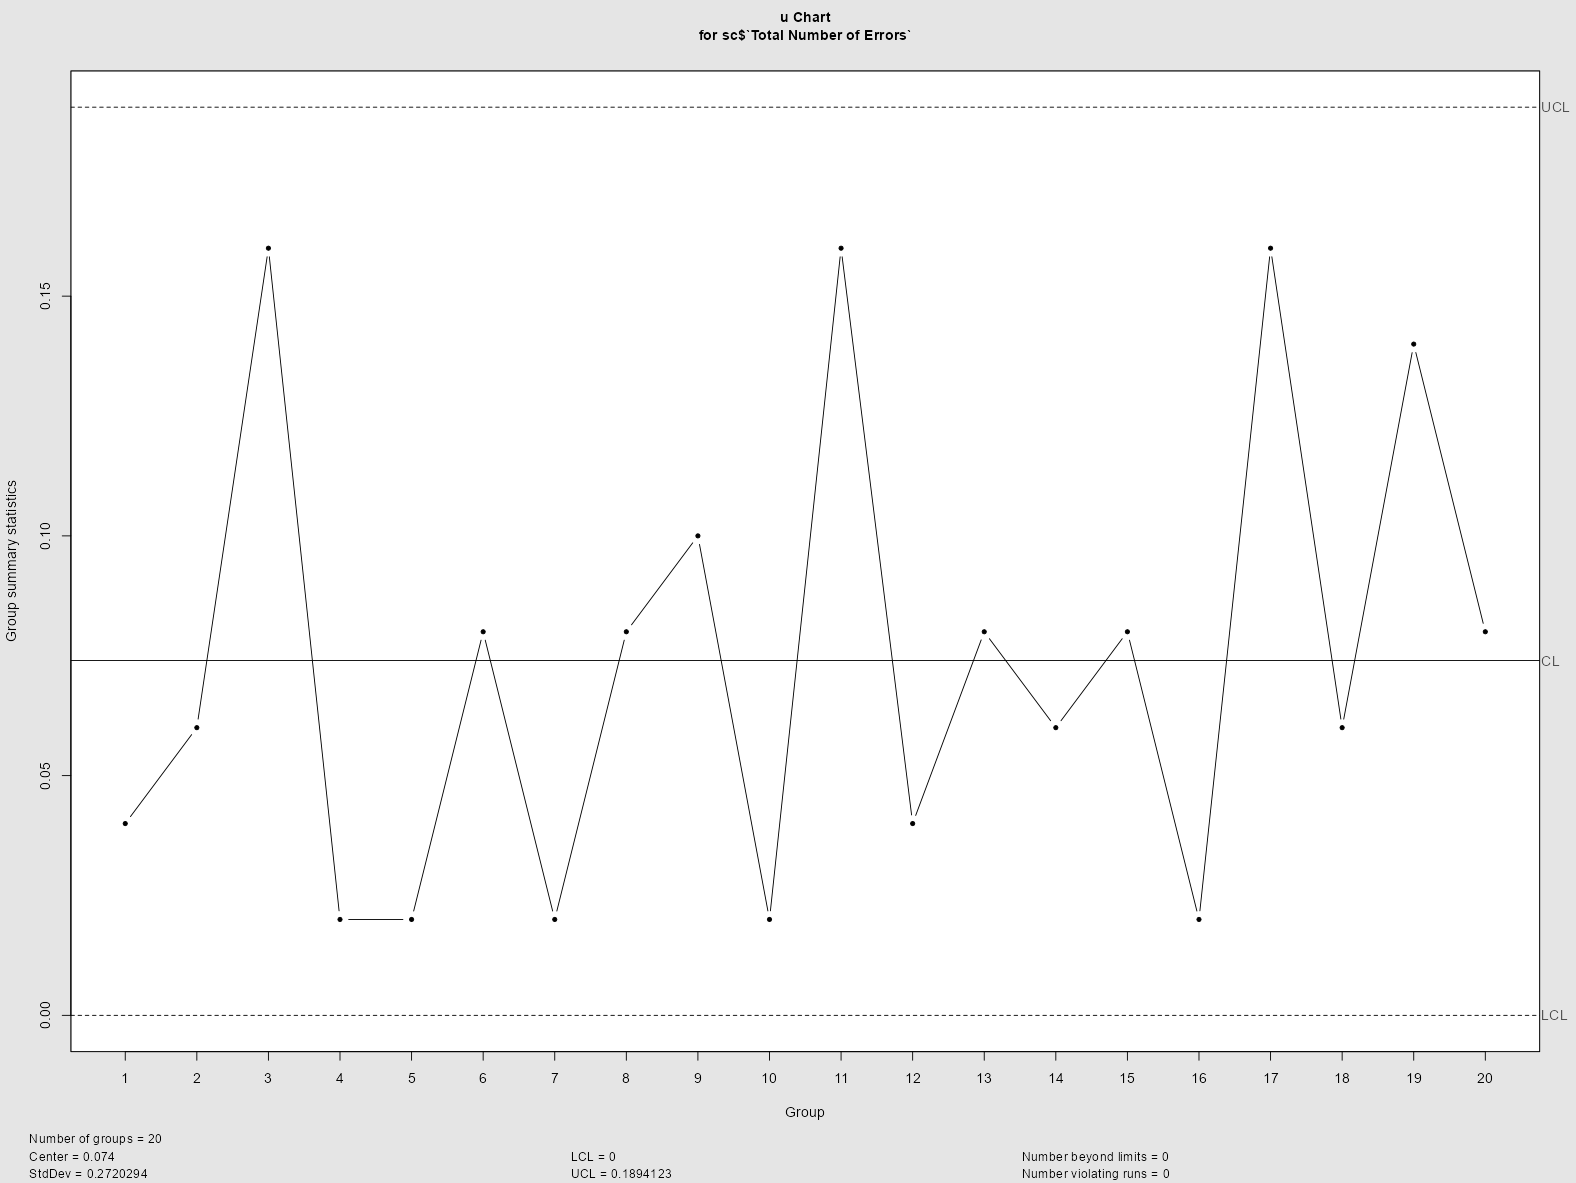

In [22]:
## Read In Supply Chain Data ##

sc <- read_xlsx("Number of Nonconformities Datasets.xlsx",
                             sheet=5)

sc |>
  glimpse()

## Plot U Chart ##

sc_chart <- qcc(sc$`Total Number of Errors`,
                     type="u",sizes=sc$`Sample Size`)

### Variable sample sizes

One nice feature of the $U$ chart is that it handles variable sample sizes much like the $\bar{x}$ and $p$ charts did. Here, we have data on the average number of defects in a textile per 50 square meters of cloth, across 10 inspected rolls, where the number of "inspection units" naturally varies roll to roll (Sheet 6).

Rows: 10
Columns: 4
$ `Roll Number`                         <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ `Number of Square Meters`             <dbl> 500, 400, 650, 500, 475, 500, 600, 525, 600, 625
$ `Total Number of Nonconformities`     <dbl> 14, 12, 20, 11, 7, 10, 21, 16, 19, 23
$ `Number of Inspection Units Per Roll` <dbl> 10.0, 8.0, 13.0, 10.0, 9.5, 10.0, 12.0, 10.5, 12.0, 12.5


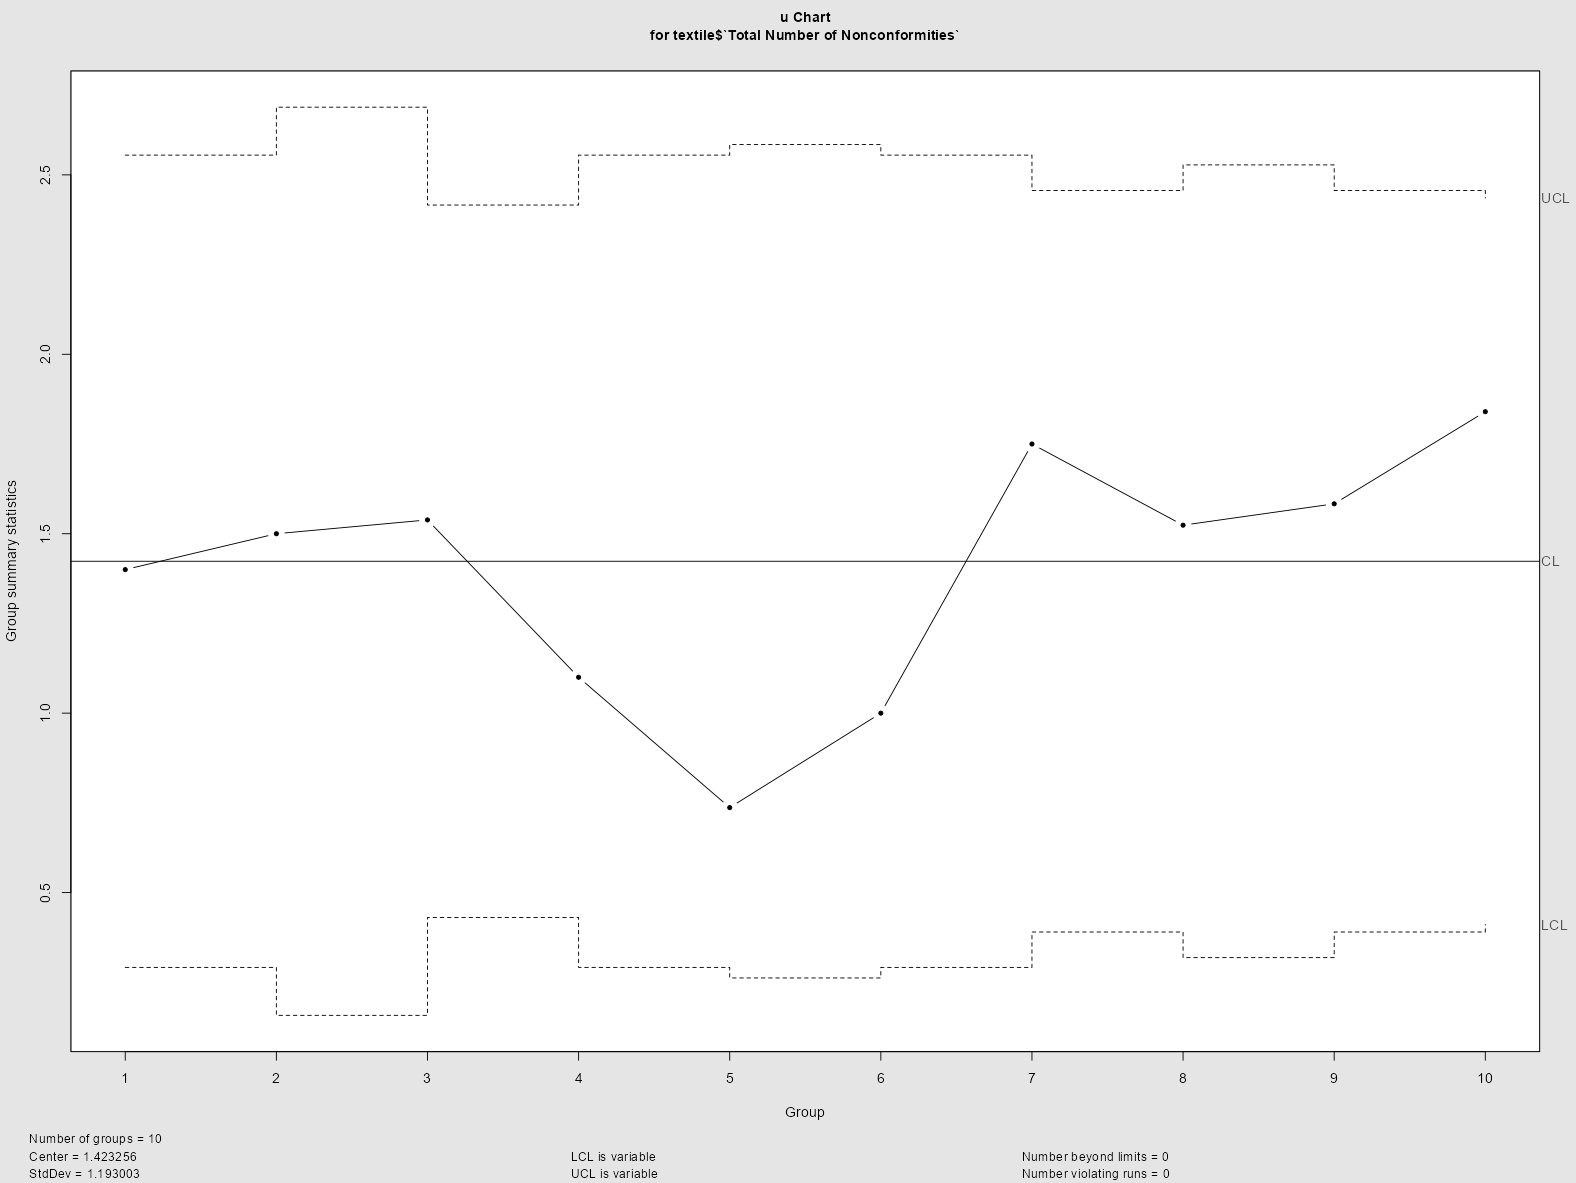

In [23]:
## Variable Sample Size U Chart ##

## Read in Textile Data ##

textile <- read_xlsx("Number of Nonconformities Datasets.xlsx",
                        sheet=6)

textile$`Number of Inspection Units Per Roll` <- textile$`Number of Square Meters`/50

textile |>
  glimpse()

## Plot U Chart ##

vu_chart <- qcc(textile$`Total Number of Nonconformities`,
                     type="u",
                     sizes=textile$`Number of Inspection Units Per Roll`,
                     plot=T)

*Two other standard ways to handle variable sample sizes with the $U$ chart, for reference:*

- **Average sample size:** $\bar{n} = \frac{1}{m}\sum_{i=1}^{m}n_i$, and build flat limits around that.
- **Standardizing each $u_i$:** $Z_i = \dfrac{u_i - \bar{u}}{\sqrt{\bar{u}/n_i}}$, plotting the standardized statistic directly against fixed $\pm3$ limits.

## OC Curves for the $C$ and $U$ Charts

So far we've built Phase I control limits for the $np$, $C$, and $U$ charts and used them to monitor Phase II data. But just like with our other charts, there are real design decisions to make. OC curves are one of the primary tools that helps us make them.

Recall: OC curves model the probability of a **Type II error**, $\beta$, a point plotting *inside* the control limits even though the process is genuinely out of control. For the $C$ chart, suppose the true process mean has shifted from an in-control value $c_0$ to a new value $c_1$:

$$ P[LCL < X < UCL \,|\, c = c_1] = \beta $$
$$ P[X < UCL \,|\, c=c_1] - P[X < LCL \,|\, c=c_1] = \beta $$

### OC Curve: Circuit Boards ($C$ Chart)

Recall from the circuit boards example: after removing the two OOC points, we estimated $\bar{c} = 19.67$, $UCL = 32.97$, and $LCL = 6.36$. Let's let R handle the heavy lifting on the OC curve itself.

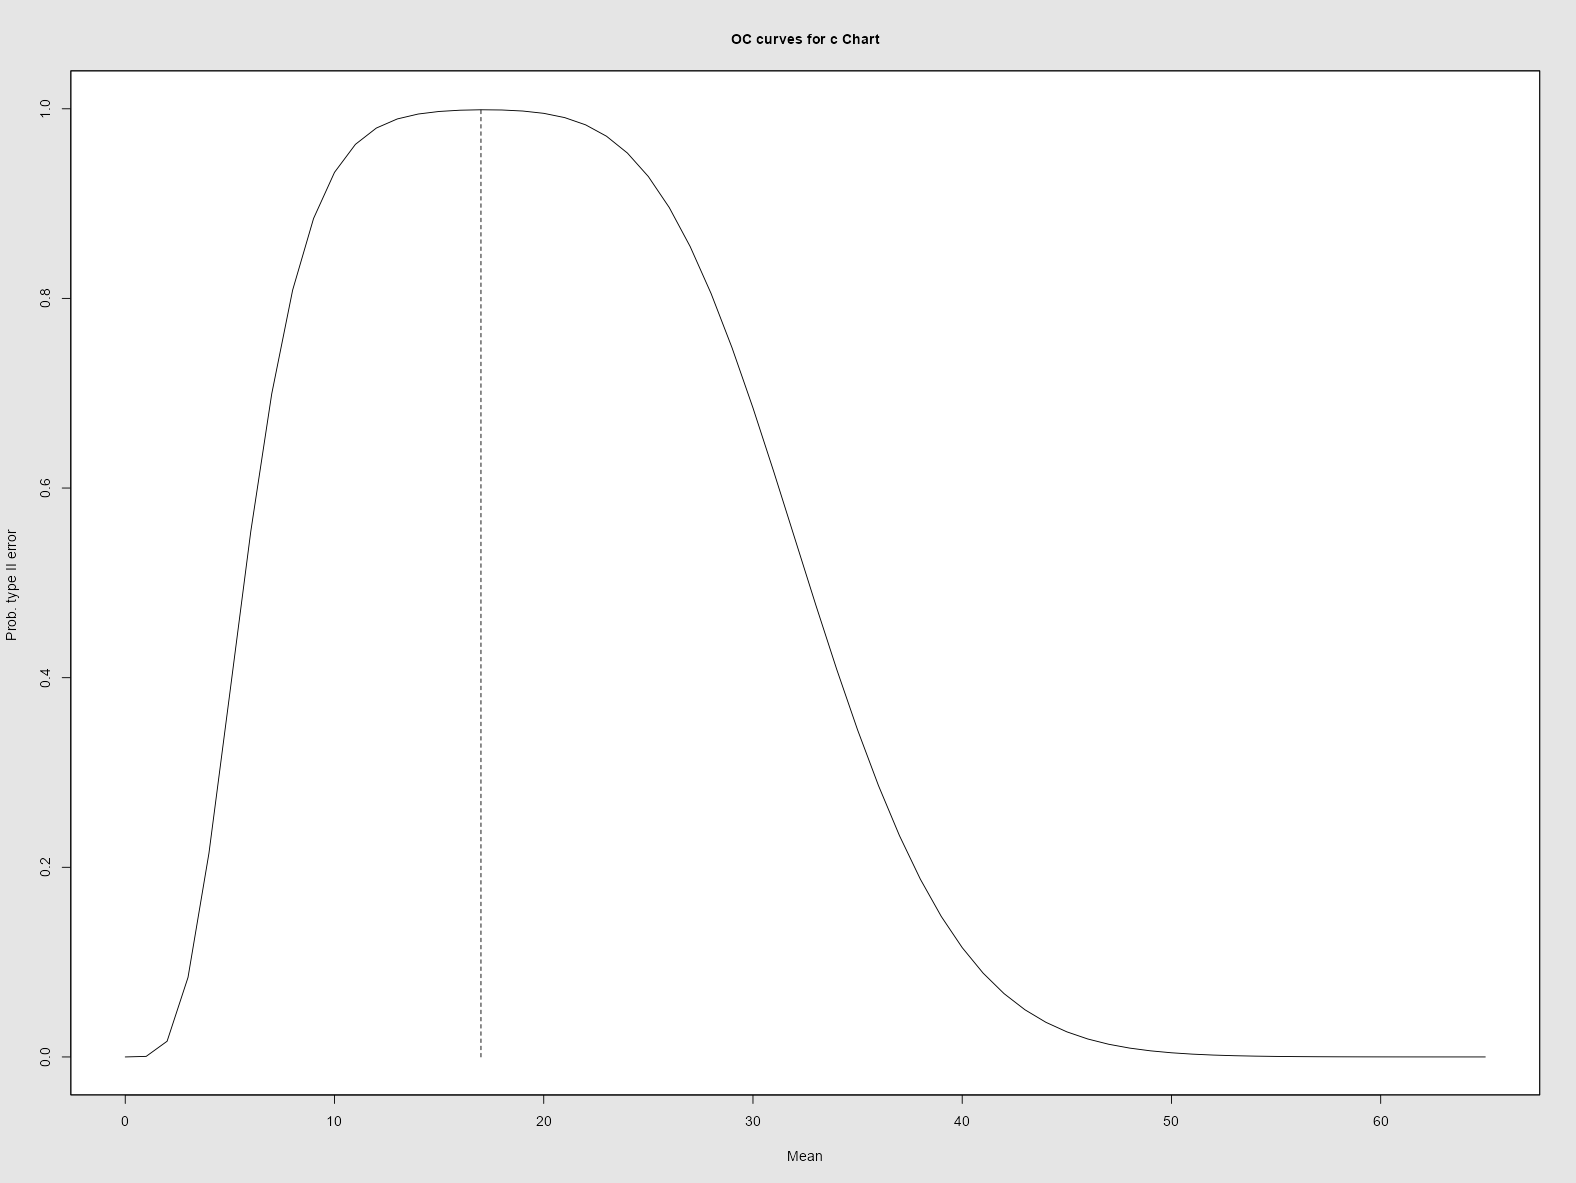

Warning message:
In oc.curves.c(circuit_chart1) :
  Some computed values for the type II error have been rounded due to the discreteness of the Poisson distribution. Thus, some ARL values might be meaningless.


In [24]:
## OC Curve for C Chart using Circuits Data ##

## Plot OC Curve ##

oc_c <- oc.curves.c(circuit_chart1)

Statistical power ($1-\beta$) of 0.80 is a common design target, which means $\beta = 0.20$. So: what values of $c_1$ get us to that power or better?

In [25]:
## Statistical power, 1 - beta, is usually desired to be 0.80 ##
## This implies beta = 0.20 ##
## So what values of c1 will give us this power (or greater)? ##

## Determine which points are closest to 0.20 ##

pointz <- abs(0.20 - oc_c)

pointz <- pointz[order(pointz)][1:2]

names(pointz)

[1] "38" "4" 

So the chart hits a power of 0.80 or better once the number of nonconformities drops to 4 or below, or rises above 38. We can express those as shift magnitudes relative to $\bar{c}$:

In [27]:
## Magnitude of Shifts ##

cat("Magnitude of Shift 1:",38/circuit_chart1$center,"\n")
cat("Magnitude of Shift 2:",4/circuit_chart1$center,"\n")

Magnitude of Shift 1: 1.932203 
Magnitude of Shift 2: 0.2033898 


And recall, targeting a power of 0.80 corresponds to:

In [28]:
## ARL1 ##

1/(1-0.20)

[1] 1.25

So in other words, for a shift of magnitude 1.93x or 0.20x, we would expect, on average, to have the chart signal OOC every 1.25 samples.

### OC Curve: Supply Chain ($U$ Chart)

The $U$ chart requires a bit more manual work. Technically, $u$ itself isn't Poisson-distributed, so we need to rewrite the formula for $\beta$ into a form we *can* work with. Recall $u = x/n$ and $x \sim POI(nC)$, so:

$$ P[u < UCL\,|\,OOC] - P[u < LCL\,|\,OOC] = \beta$$
$$ P[x/n < UCL\,|\,OOC] - P[x/n < LCL \,|\, OOC] = \beta $$
$$ P[x < nUCL\,|\,OOC] - P[x < nLCL \,|\, OOC] = \beta$$

Since $n \times UCL$ and $n \times LCL$ won't generally be integers, in practice we round $LCL$ up and $UCL$ down.

There's no built-in `qcc` function to plot the OC curve for a $U$ chart the way there is for the $C$ chart, so we'll build it manually using the supply chain data.

In [29]:
## Find OC Curve for U Chart using Supply Chain Data ##

## Okay great! The problem here is that there isn't a built-in function ##
## in the qcc package to plot the OC Curve, so we have to do it manually ##

cu <- sc_chart$center
nlcl <- ceiling(50*sc_chart$limits[1])
nucl <- floor(50*sc_chart$limits[2])

betas <- vector("double",length=51)

for(i in 1:length(betas)){
  
  betas[i] <- ppois(nucl,lambda=i-1) - ppois(nlcl,lambda=i-1)
  
}

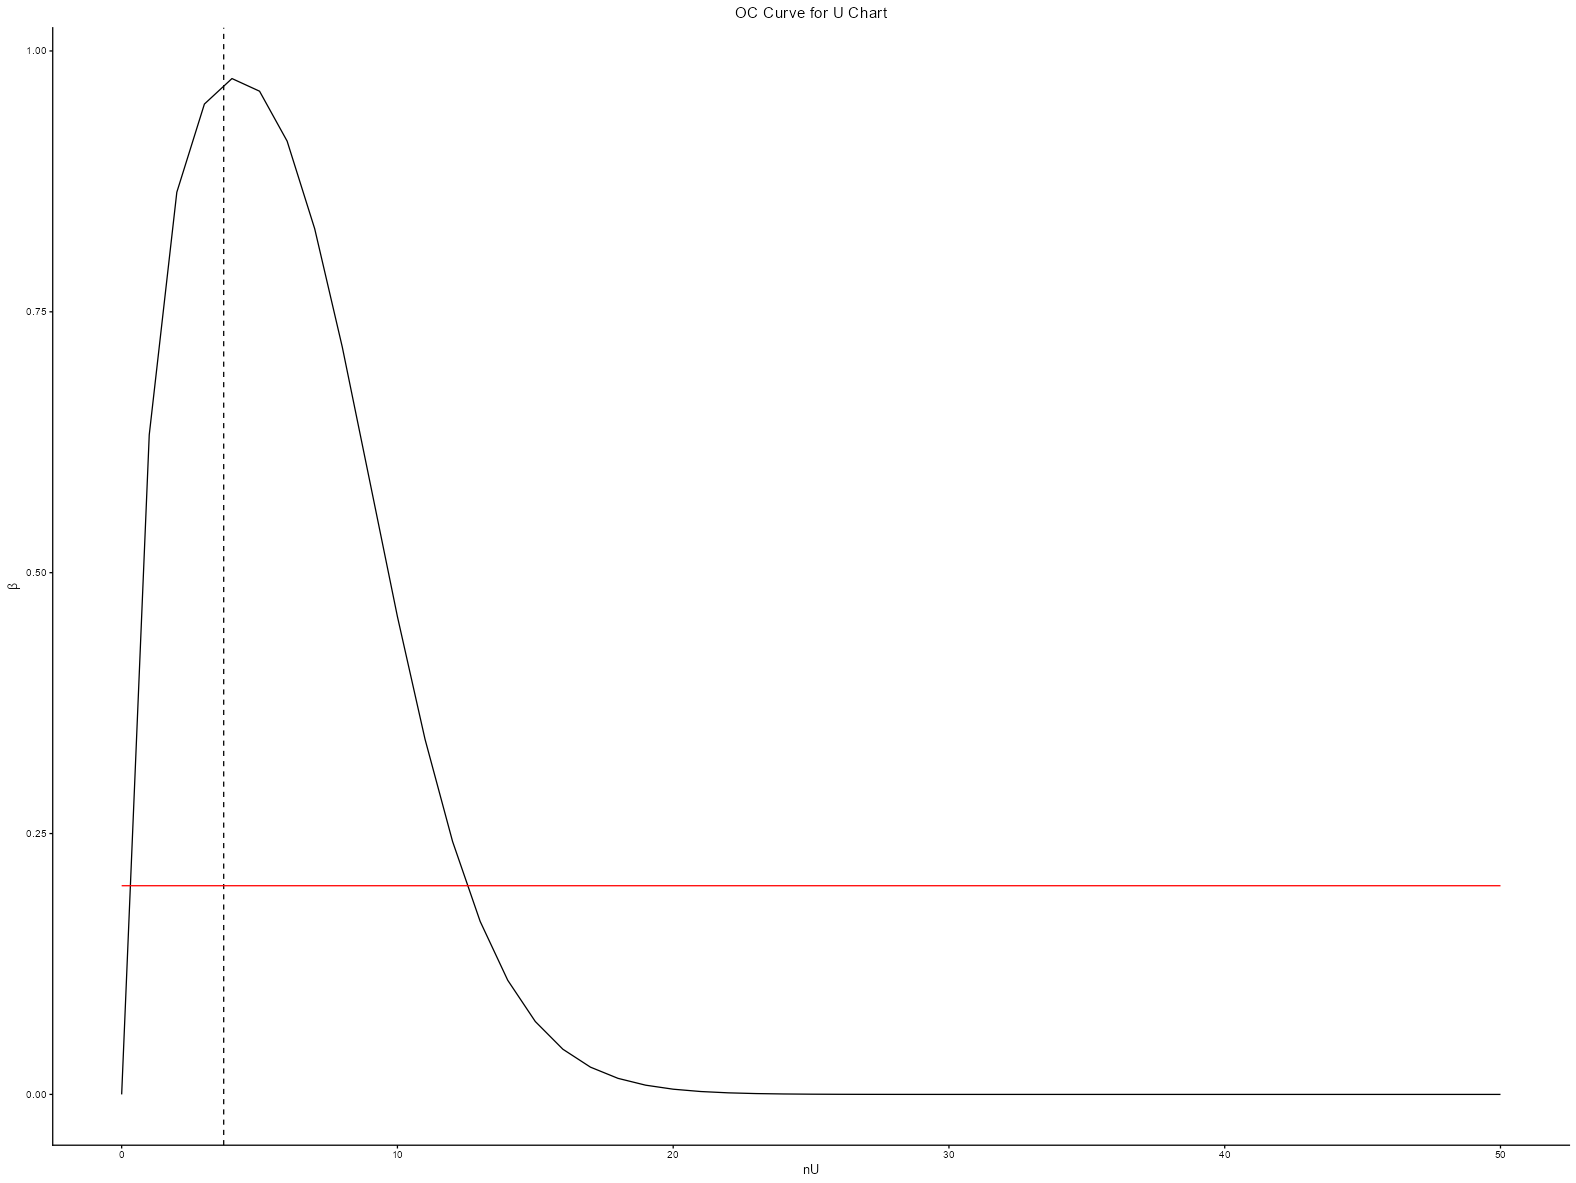

In [30]:
ggplot() + geom_line(aes(x=seq(0,50),y=betas)) + 
  geom_vline(xintercept = 50*cu,linetype = "dashed") +
  geom_segment(aes(x=0,y=0.2,xend=length(betas)-1,yend=0.20),color='red') +
  labs(x = "nU",
       y = quote(beta),
       title = "OC Curve for U Chart") +
  theme_classic() +
  theme(plot.title = element_text(hjust=0.50))

The dashed vertical line marks the in-control center ($n\bar{u}$); the red horizontal line marks our $\beta = 0.20$ target. Where the curve crosses that red line tells us the values of $nU$ at which the chart achieves at least 80% power — exactly the same design logic as the $C$ chart example, just built by hand since `qcc` doesn't do it for us here.

## Final Remarks

Between the $p$ chart from last week and the $np$, $C$, and $U$ charts this week, we now have a full toolkit for monitoring attribute data:

| Chart | Use when you care about... |
|---|---|
| $p$ | The **proportion** of nonconforming units |
| $np$ | The **count** of nonconforming units (same info as $p$, different scale) |
| $C$ | The **number of nonconformities per unit**, not just pass/fail |
| $U$ | The **average number of nonconformities per batch**, especially with variable sample sizes |

As with every chart we've covered, the underlying statistics only get you halfway there. The chart *design* (sample size, sampling interval, and control limit width) is what determines whether the chart will actually catch the shifts you care about in a reasonable amount of time. OC curves and ARL remain the right tools for making those design decisions, whether you're working with a mean, a proportion, or a count.

## Additional Reading

1. [Saghir & Lin (2014)](https://onlinelibrary.wiley.com/doi/abs/10.1002/qre.1642)
2. [Mahmood & Xie (2019)](https://onlinelibrary.wiley.com/doi/abs/10.1002/qre.2547)
3. [Sindhu et al. (2025)](https://onlinelibrary.wiley.com/doi/abs/10.1002/qre.3745)
